# I. 가설 검증

In [1]:
import matplotlib.pyplot as plt
from matplotlib import font_manager, rc
import platform

# OS별 기본 폰트 설정
if platform.system() == 'Windows':  # 윈도우
    font_path = "C:/Windows/Fonts/malgun.ttf"  # 맑은 고딕
elif platform.system() == 'Darwin':  # macOS
    font_path = "/System/Library/Fonts/AppleGothic.ttf"
else:  # 리눅스 (예: Colab)
    font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"

font_name = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False  # 음수 깨짐 방지

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data\smallbiz-data-final.csv')

C:\Users\yura1\AppData\Local\Temp\ipykernel_34916\539403987.py:6: DtypeWarning: Columns (38,39) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data\smallbiz-data-final.csv')


## 가설 0. 매출/거래건수객단가가 낮거나 적으면 폐업률이 높다

-> 매출/거래건수/객단가의 양끝은 폐업률이 높으며 그 외에는 대체적으로 낮거나 적으면 폐업률이 높음 

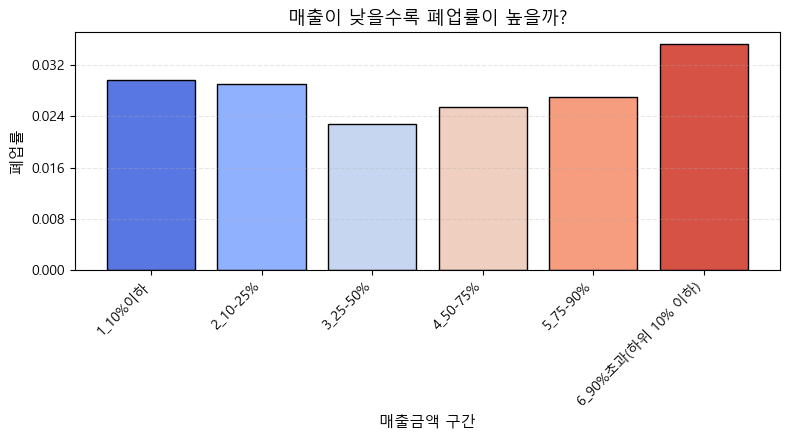

,매출금액 구간,폐업률
0,1_10%이하,0.029662
1,2_10-25%,0.029090
2,3_25-50%,0.022856
3,4_50-75%,0.025507
4,5_75-90%,0.026998
5,6_90%초과(하위 10% 이하),0.035410


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MaxNLocator

# 1. 기본 컬럼 체크
if ("매출금액 구간" not in df.columns) or ("폐업여부" not in df.columns):
    raise KeyError("'매출금액 구간' 또는 '폐업여부' 컬럼이 없습니다!")

# 2. 필요한 부분 추출
use = df[["매출금액 구간", "폐업여부"]].dropna().copy()

# 3. 구간 순서 정렬 키 생성
def sort_by_prefix_num(x):
    try:
        return int(str(x).split("_", 1)[0])
    except:
        return 9999

order = sorted(use["매출금액 구간"].unique(), key=sort_by_prefix_num)

# 4. 폐업여부 수치 변환 (혹시 문자열일 경우)
use["폐업여부"] = pd.to_numeric(use["폐업여부"], errors="coerce")

# 5. 폐업률 계산 (단순 groupby)
grp = (
    use.groupby("매출금액 구간", observed=True)["폐업여부"]
    .mean()
    .reindex(order)
    .reset_index(name="폐업률")
)

# 6. 시각화
plt.figure(figsize=(8, 4.5))
colors = plt.cm.coolwarm(np.linspace(0.1, 0.9, len(grp)))
plt.bar(grp["매출금액 구간"].astype(str), grp["폐업률"], color=colors, edgecolor="black")

plt.title("매출이 낮을수록 폐업률이 높을까?", fontsize=13)
plt.xlabel("매출금액 구간", fontsize=11)
plt.ylabel("폐업률", fontsize=11)
plt.xticks(rotation=45, ha="right")
plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=6))
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

# 7. 확인용 테이블 출력
display(grp)


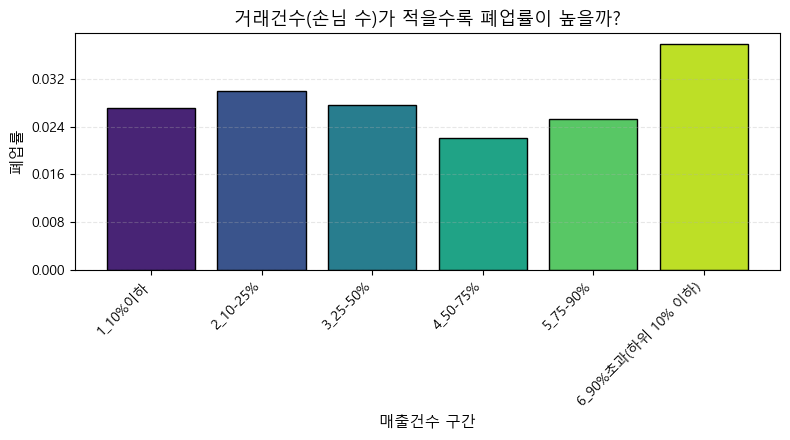

,매출건수 구간,폐업률
0,1_10%이하,0.027182
1,2_10-25%,0.030024
2,3_25-50%,0.027710
3,4_50-75%,0.022094
4,5_75-90%,0.025273
5,6_90%초과(하위 10% 이하),0.037848


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MaxNLocator

# 1. 기본 컬럼 체크
if ("매출건수 구간" not in df.columns) or ("폐업여부" not in df.columns):
    raise KeyError("'매출건수 구간' 또는 '폐업여부' 컬럼이 없습니다!")

# 2. 필요한 부분 추출
use = df[["매출건수 구간", "폐업여부"]].dropna().copy()

# 3. 구간 순서 정렬 키 생성
def sort_by_prefix_num(x):
    try:
        return int(str(x).split("_", 1)[0])
    except:
        return 9999

order = sorted(use["매출건수 구간"].unique(), key=sort_by_prefix_num)

# 4. 폐업여부 수치 변환 (혹시 문자열일 경우)
use["폐업여부"] = pd.to_numeric(use["폐업여부"], errors="coerce")

# 5. 폐업률 계산 (단순 groupby)
grp = (
    use.groupby("매출건수 구간", observed=True)["폐업여부"]
    .mean()
    .reindex(order)
    .reset_index(name="폐업률")
)

# 6. 시각화
plt.figure(figsize=(8, 4.5))
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(grp)))
plt.bar(grp["매출건수 구간"].astype(str), grp["폐업률"], color=colors, edgecolor="black")

plt.title("거래건수(손님 수)가 적을수록 폐업률이 높을까?", fontsize=13)
plt.xlabel("매출건수 구간", fontsize=11)
plt.ylabel("폐업률", fontsize=11)
plt.xticks(rotation=45, ha="right")
plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=6))
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

# 7. 확인용 테이블 출력
display(grp)


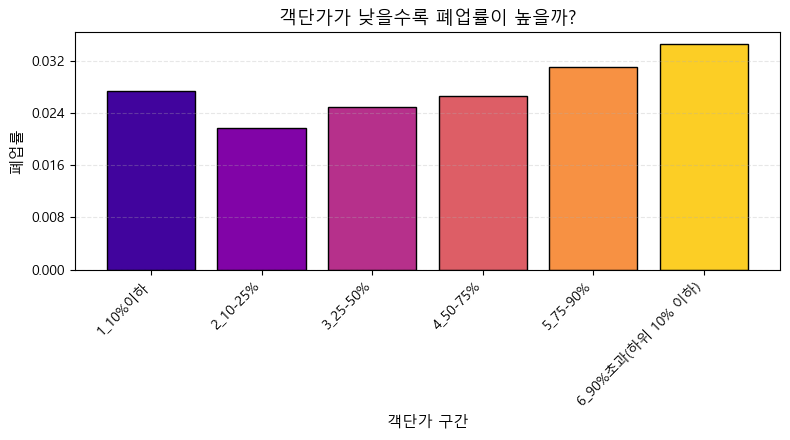

,객단가 구간,폐업률
0,1_10%이하,0.027391
1,2_10-25%,0.021767
2,3_25-50%,0.024978
3,4_50-75%,0.026653
4,5_75-90%,0.031046
5,6_90%초과(하위 10% 이하),0.034639


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MaxNLocator

# 1) 기본 컬럼 체크
if ("객단가 구간" not in df.columns) or ("폐업여부" not in df.columns):
    raise KeyError("'객단가 구간' 또는 '폐업여부' 컬럼이 없습니다!")

# 2) 필요한 부분 추출
use = df[["객단가 구간", "폐업여부"]].dropna().copy()

# 3) 구간 순서 정렬 키 (접두 숫자_ 기준)
def sort_by_prefix_num(x):
    try:
        return int(str(x).split("_", 1)[0])
    except:
        return 9999

order = sorted(use["객단가 구간"].unique(), key=sort_by_prefix_num)

# 4) 폐업여부 수치 변환 (문자일 수도 있으니 안전 변환)
use["폐업여부"] = pd.to_numeric(use["폐업여부"], errors="coerce")

# 5) 폐업률 계산
grp = (
    use.groupby("객단가 구간", observed=True)["폐업여부"]
       .mean()
       .reindex(order)
       .reset_index(name="폐업률")
)

# 6) 시각화
plt.figure(figsize=(8, 4.5))
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(grp)))
plt.bar(grp["객단가 구간"].astype(str), grp["폐업률"], color=colors, edgecolor="black")

plt.title("객단가가 낮을수록 폐업률이 높을까?", fontsize=13)
plt.xlabel("객단가 구간", fontsize=11)
plt.ylabel("폐업률", fontsize=11)
plt.xticks(rotation=45, ha="right")
plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=6))
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

# 7) 확인용 테이블
display(grp)


## 가설 1: 50, 60세대들이 많아지면 폐업률이 높아진다. (X)

--- 1. '5060대 고객 비중' 파생변수 생성 ---
   5060대 고객 비중  TARGET
0        100.0       0
1        100.0       0
2        100.0       0
3         50.0       0
4         33.3       0
--- 1. 파생변수 생성 완료 ---

--- 2. 가맹점별 평균 데이터로 집계 ---
집계 후 데이터 크기: (4183, 3)
--- 2. 가맹점별 집계 완료 ---

--- 3. EDA 및 가설 검증 시작 ---

[통계적 비교]
TARGET(폐업 여부)별 '평균 5060대 고객 비중' (%):
TARGET
0    34.410459
1    28.722601
Name: avg_5060_prop, dtype: float64

[시각화 1: Box Plot 생성 중...]
 -> 'eda_boxplot_5060s.png' (Box Plot) 저장 완료.

[시각화 2: Density Plot 생성 중...]
 -> 'eda_density_5060s.png' (Density Plot) 저장 완료.

--- 3. EDA 및 가설 검증 완료 ---


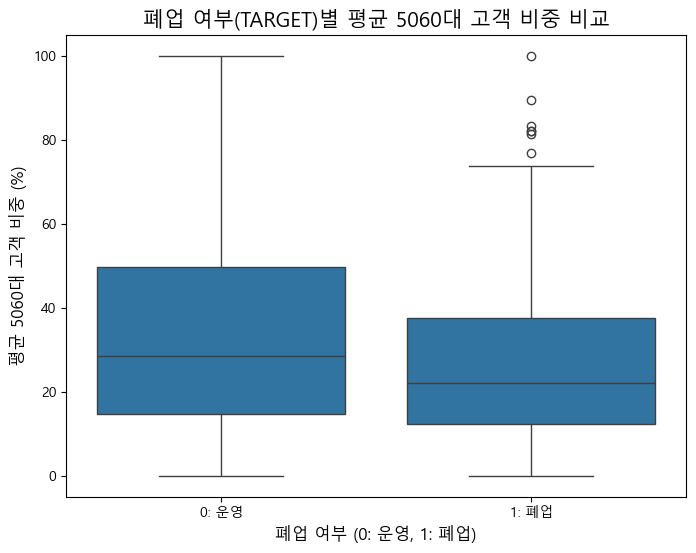

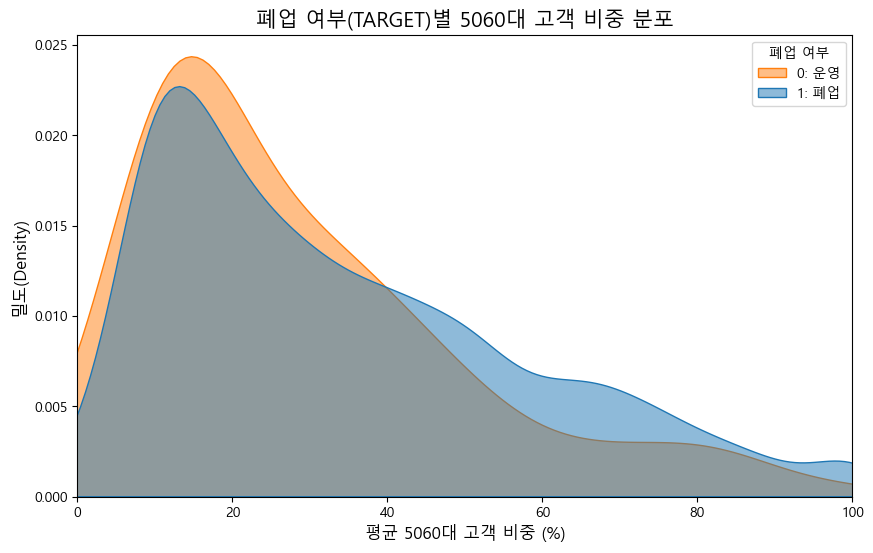

In [8]:
# 결과 해석
# 폐업을 안 한 가게의 50,60대 평균 이용고객이 34.4% 폐업을 한 가게의 비율이 28.5%
# 결과를 보아 기존의 가설은 기각되었다.
# 오히려 5060이 많으면 가게가 잘 운영이 된다를 보여줄 수 있는 지표
# 5060이 2030보다 구매력이 안정적이거나, 한 가게를 꾸준히 이용하는 '단골' 성향이 강해서 그런 것은 아닐까?

# ====================================================
# "5060대 손님 비중" 가설 검증
# ====================================================
df['TARGET'] = df['폐업일'].notna().astype(int)

# ----------------------------------------------------
# 파생변수 생성: '5060대 고객 비중'
# ----------------------------------------------------
print("--- 1. '5060대 고객 비중' 파생변수 생성 ---")
# 50대, 60대 이상 남녀 고객 비중을 모두 합산
df['5060대 고객 비중'] = df['남성 50대 고객 비중'] + df['남성 60대이상 고객 비중'] + \
                          df['여성 50대 고객 비중'] + df['여성 60대이상 고객 비중']
print(df[['5060대 고객 비중', 'TARGET']].head())
print("--- 1. 파생변수 생성 완료 ---\n")

# ----------------------------------------------------
# 데이터 집계 (가맹점 레벨로)
# ----------------------------------------------------
print("--- 2. 가맹점별 평균 데이터로 집계 ---")
# 이유: 월별 데이터를 그대로 쓰면, 오래 운영한 가맹점의 영향력이 커지므로
# 가맹점별(Store-level) 평균으로 집계합니다.
store_level_df = df.groupby('가맹점구분번호').agg(
    avg_5060_prop = ('5060대 고객 비중', 'mean'),
    TARGET = ('TARGET', 'first')
).reset_index()
print(f"집계 후 데이터 크기: {store_level_df.shape}")
print("--- 2. 가맹점별 집계 완료 ---\n")

# ----------------------------------------------------
# 통계 및 시각화
# ----------------------------------------------------
print("--- 3. EDA 및 가설 검증 시작 ---")

# 통계적 비교 (숫자로 확인)
print("\n[통계적 비교]")
print("TARGET(폐업 여부)별 '평균 5060대 고객 비중' (%):")
mean_comparison = store_level_df.groupby('TARGET')['avg_5060_prop'].mean()
print(mean_comparison)

# 시각화 1: Box Plot (차이 비교)
print("\n[시각화 1: Box Plot 생성 중...]")
plt.figure(figsize=(8, 6))
sns.boxplot(x='TARGET', y='avg_5060_prop', data=store_level_df)
plt.title('폐업 여부(TARGET)별 평균 5060대 고객 비중 비교', fontsize=15)
plt.xlabel('폐업 여부 (0: 운영, 1: 폐업)', fontsize=12)
plt.ylabel('평균 5060대 고객 비중 (%)', fontsize=12)
plt.xticks([0, 1], ['0: 운영', '1: 폐업'])
plt.savefig('eda_boxplot_5060s.png')
print(" -> 'eda_boxplot_5060s.png' (Box Plot) 저장 완료.")

# 시각화 2: Density Plot (분포 비교)
print("\n[시각화 2: Density Plot 생성 중...]")
plt.figure(figsize=(10, 6))
sns.kdeplot(data=store_level_df, x='avg_5060_prop', hue='TARGET',
            fill=True, common_norm=False, alpha=0.5)
plt.title('폐업 여부(TARGET)별 5060대 고객 비중 분포', fontsize=15)
plt.xlabel('평균 5060대 고객 비중 (%)', fontsize=12)
plt.ylabel('밀도(Density)', fontsize=12)
plt.xlim(0, 100)
# 범례(Legend) 설정
hue_order = sorted(store_level_df['TARGET'].unique())
labels = [f'{val}: {"폐업" if val == 1 else "운영"}' for val in hue_order]
plt.legend(title='폐업 여부', labels=labels)

plt.savefig('eda_density_5060s.png')
print(" -> 'eda_density_5060s.png' (Density Plot) 저장 완료.")
print("\n--- 3. EDA 및 가설 검증 완료 ---")

## 가설 2. 매출 구간이 낮으면 폐업율이 높다.

-> 가장 높았지만 유의미한 정도는 아니다.

--- 1. '매출금액 구간'의 논리적 순서 정의 ---
매출 구간 순서: ['1_10%이하', '2_10-25%', '3_25-50%', '4_50-75%', '5_75-90%', '6_90%초과(하위 10% 이하)']

--- 2. '매출금액 구간'별 폐업(TARGET=1) 비율 계산 ---
매출 구간별 폐업(TARGET=1) 비율(%):
매출금액 구간
1_10%이하               2.966246
2_10-25%              2.909008
3_25-50%              2.285557
4_50-75%              2.550738
5_75-90%              2.699767
6_90%초과(하위 10% 이하)    3.541008
Name: 1, dtype: float64
--- 2. 비율 계산 완료 ---

--- 3. '폐업 비율' 단독 막대 그래프 시각화 ---
 -> 'eda_bar_closure_rate_sales.png' (폐업 비율 단독 막대 그래프) 저장 완료.

--- 3. EDA 및 가설 검증 완료 ---


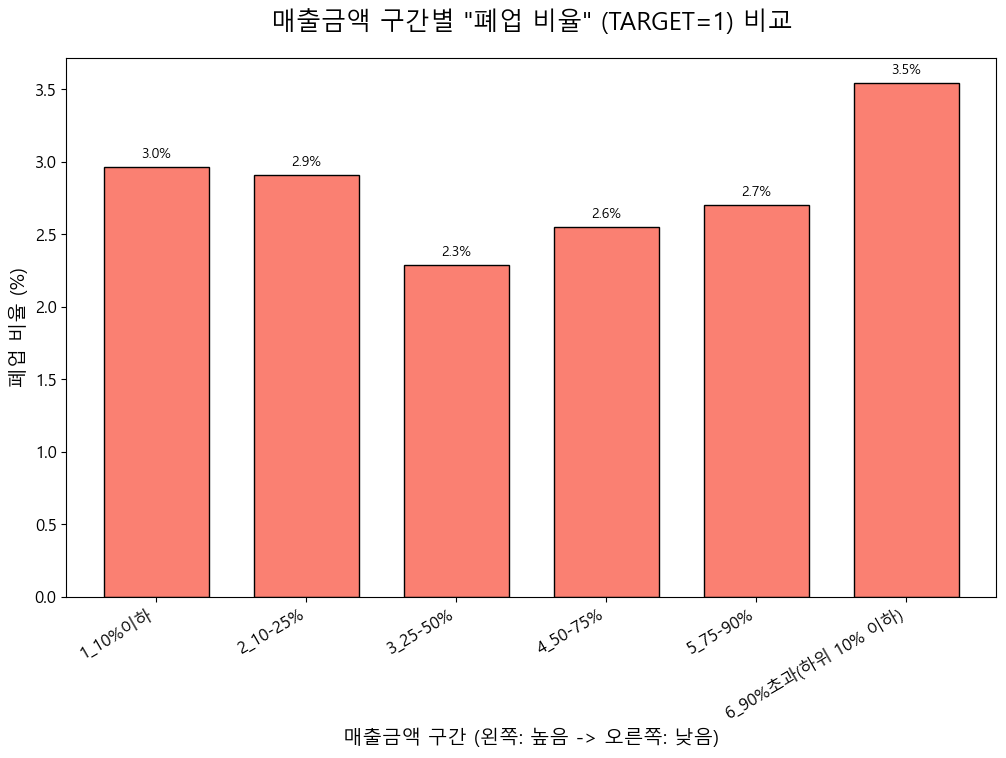

In [9]:
# 결과 해석
# --- '매출금액 구간'별 폐업(TARGET=1) 비율 계산 ---
# 매출 구간별 폐업(TARGET=1) 비율(%):
# 매출금액 구간
# 1_10%이하               2.966246
# 2_10-25%              2.908787
# 3_25-50%              2.284404
# 4_50-75%              2.549327
# 5_75-90%              2.602230
# 6_90%초과(하위 10% 이하)    3.394161

# 하위 10프로의 구간에선 3프로이긴 하지만 상위 10프로 구간도
# 3프로에 가깝기 때문에 매출구간이 무조건 폐업을 의미하지는 않는다.
# 모든 구간에서 균등하게 일어나는 이유는 뭘까?
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ====================================================
# EDA 2: "매출금액 구간" (폐업 비율 단독 비교)
# ====================================================

# ----------------------------------------------------
# 1. '매출금액 구간' 순서 정의
# ----------------------------------------------------
print("--- 1. '매출금액 구간'의 논리적 순서 정의 ---")
# '1_10%이하' (상위 10%)가 가장 매출이 높음
# '6_90%초과(하위 10% 이하)'가 가장 매출이 낮음
sales_order = [
    '1_10%이하',
    '2_10-25%',
    '3_25-50%',
    '4_50-75%',
    '5_75-90%',
    '6_90%초과(하위 10% 이하)'
]

# '정보없음'은 분석에서 제외
df_filtered = df[df['매출금액 구간'] != '정보없음']
print(f"매출 구간 순서: {sales_order}\n")


# ----------------------------------------------------
# 2. 그룹별 비율 계산 (*** 들여쓰기 수정 ***)
# ----------------------------------------------------
print("--- 2. '매출금액 구간'별 폐업(TARGET=1) 비율 계산 ---")

# (들여쓰기 오류 수정)
prop_df = df_filtered.groupby('매출금액 구간')['TARGET'] \
                     .value_counts(normalize=True) \
                     .mul(100) \
                     .unstack() \
                     .fillna(0) # TARGET=0 또는 1만 있는 경우 NaN 방지

# 정의한 순서(sales_order)대로 DataFrame을 재정렬
prop_df = prop_df.reindex(sales_order)

# (참고) TARGET=1 (폐업) 비율만 따로 확인
if 1 in prop_df.columns:
    print("매출 구간별 폐업(TARGET=1) 비율(%):")
    print(prop_df[1])
else:
    print("데이터에 폐업(TARGET=1) 샘플이 없습니다.")

print("--- 2. 비율 계산 완료 ---\n")


# ----------------------------------------------------
# 3. "폐업 비율" 단독 막대 그래프 시각화 (*** 수정된 부분 ***)
# ----------------------------------------------------
print("--- 3. '폐업 비율' 단독 막대 그래프 시각화 ---")

if 1 not in prop_df.columns:
    print("(!) 폐업(TARGET=1) 데이터가 없어 그래프를 그릴 수 없습니다.")
else:
    # '폐업(TARGET=1)' 비율만 선택
    closure_rate_series = prop_df[1]

    plt.figure(figsize=(12, 7))

    # '폐업 비율' 시리즈를 직접 막대 그래프로 그림
    ax = closure_rate_series.plot(
        kind='bar',
        figsize=(12, 7),
        color='salmon',      # '폐업'을 잘 보여주는 단일 색상
        edgecolor='black',   # 막대 테두리
        width=0.7
    )

    plt.title('매출금액 구간별 "폐업 비율" (TARGET=1) 비교', fontsize=18, pad=20)
    plt.xlabel('매출금액 구간 (왼쪽: 높음 -> 오른쪽: 낮음)', fontsize=14)
    plt.ylabel('폐업 비율 (%)', fontsize=14) # Y축이 0~100%가 아닌, 폐업 비율 범위로 자동 조정됨
    plt.xticks(rotation=30, ha='right', fontsize=12)
    plt.yticks(fontsize=12)

    # 각 막대 위에 비율(%) 텍스트 표시
    for p in ax.patches:
        ax.annotate(
            f"{p.get_height():.1f}%", # 소수점 첫째 자리
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center',
            va='center',
            xytext=(0, 9),
            textcoords='offset points',
            fontsize=10
        )

    plt.savefig('eda_bar_closure_rate_sales.png')
    print(" -> 'eda_bar_closure_rate_sales.png' (폐업 비율 단독 막대 그래프) 저장 완료.")

print("\n--- 3. EDA 및 가설 검증 완료 ---")

## 가설 3. 매출이 줄어들면 폐업을 할 확률이 높아진다. (O)

--- 1. '매출금액 구간'을 '매출점수'로 변환 ---
      가맹점구분번호    기준년월             매출금액 구간  매출점수
0  000F03E44A  202301  6_90%초과(하위 10% 이하)   6.0
1  000F03E44A  202302  6_90%초과(하위 10% 이하)   6.0
2  000F03E44A  202303  6_90%초과(하위 10% 이하)   6.0
3  000F03E44A  202304  6_90%초과(하위 10% 이하)   6.0
4  000F03E44A  202305  6_90%초과(하위 10% 이하)   6.0
--- 1. '매출점수' 변환 완료 ---

--- 2. 가맹점별 '월순서' 인덱스 생성 ---
      가맹점구분번호    기준년월  월순서
0  000F03E44A  202301    1
1  000F03E44A  202302    2
2  000F03E44A  202303    3
3  000F03E44A  202304    4
4  000F03E44A  202305    5
--- 2. '월순서' 생성 완료 ---

--- 3. 가맹점별 매출 트렌드(기울기) 계산 중... (시간이 다소 걸릴 수 있음) ---


C:\Users\yura1\AppData\Local\Temp\ipykernel_35072\2990734647.py:53: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  slope_series = df.groupby('가맹점구분번호').apply(calculate_slope)


트렌드 분석 대상 가맹점 수: 4157
            매출점수_트렌드(기울기)  TARGET
가맹점구분번호                          
000F03E44A      -0.029565       0
002816BA73       0.005217       0
003473B465       0.031304       0
003AC99735      -0.007826       0
0041E4E5AE       0.012174       0
--- 3. 기울기 계산 완료 ---

--- 4. EDA 및 가설 검증 시작 ---

[통계적 비교]
TARGET(폐업 여부)별 '평균 매출점수 트렌드(기울기)':
TARGET
0   -0.043646
1   -0.008811
Name: 매출점수_트렌드(기울기), dtype: float64

* 기울기 > 0 : 매출 감소 추세 (등급 나빠짐)
* 기울기 < 0 : 매출 증가 추세 (등급 좋아짐)


[시각화 1: Box Plot 생성 중...]
 -> 'eda_boxplot_sales_trend.png' (Box Plot) 저장 완료.

[시각화 2: Density Plot 생성 중...]
 -> 'eda_density_sales_trend.png' (Density Plot) 저장 완료.

--- 4. EDA 및 가설 검증 완료 ---


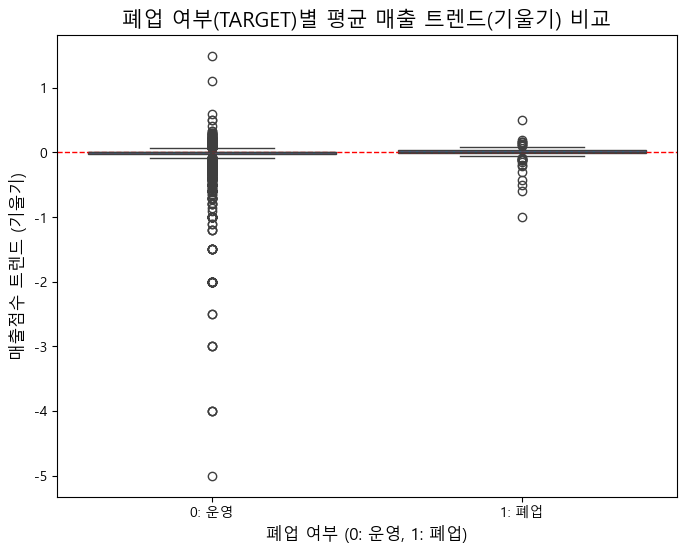

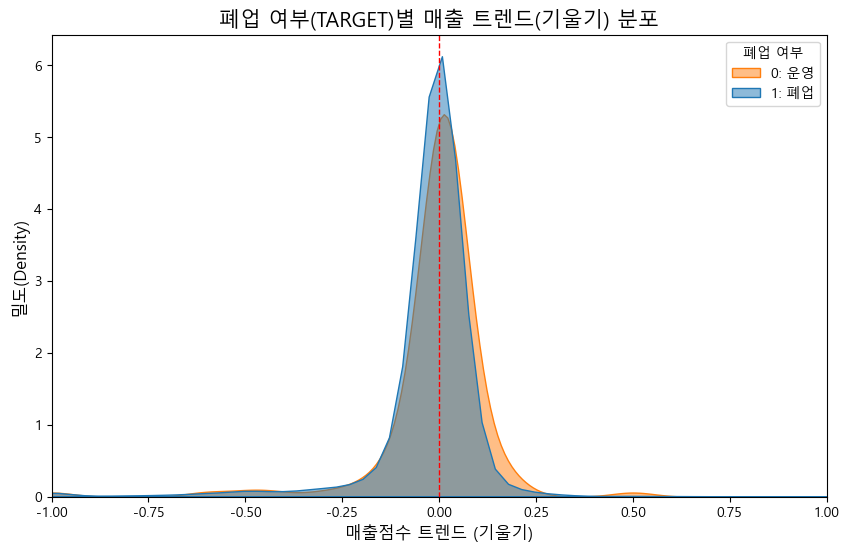

In [10]:
# 결과해석
# 폐업을 한 가게가 보통 기울기가 좀 더 급격했다는 것을 그래프를 통해 알 수 있다.

# ----------------------------------------------------
# 1. '매출금액 구간'을 수치(점수)로 변환
# ----------------------------------------------------
print("--- 1. '매출금액 구간'을 '매출점수'로 변환 ---")
# 점수가 높을수록 매출이 '낮은' 것 (1점=매출 높음, 6점=매출 낮음)
sales_map = {
    '1_10%이하': 1,
    '2_10-25%': 2,
    '3_25-50%': 3,
    '4_50-75%': 4,
    '5_75-90%': 5,
    '6_90%초과(하위 10% 이하)': 6,
    '정보없음': 3.5 # (중간값인 3.5로 처리)
}
df['매출점수'] = df['매출금액 구간'].map(sales_map).fillna(3.5)
print(df[['가맹점구분번호', '기준년월', '매출금액 구간', '매출점수']].head())
print("--- 1. '매출점수' 변환 완료 ---\n")


# ----------------------------------------------------
# 2. 가맹점별 '시간 인덱스' 생성
# ----------------------------------------------------
print("--- 2. 가맹점별 '월순서' 인덱스 생성 ---")
# 각 가맹점별로 1, 2, 3, ... 순서를 매김
df['월순서'] = df.groupby('가맹점구분번호').cumcount() + 1
print(df[['가맹점구분번호', '기준년월', '월순서']].head())
print("--- 2. '월순서' 생성 완료 ---\n")


# ----------------------------------------------------
# 3. 가맹점별 '매출 트렌드(기울기)' 계산
# ----------------------------------------------------
print("--- 3. 가맹점별 매출 트렌드(기울기) 계산 중... (시간이 다소 걸릴 수 있음) ---")

# 기울기 계산 함수 정의
def calculate_slope(group):
    # 최소 2개 이상의 월 데이터가 있어야 기울기 계산 가능
    if len(group) < 2:
        return np.nan

    # np.polyfit(X, Y, 1) -> [기울기, 절편] 반환
    # X = 월순서, Y = 매출점수
    try:
        slope, _ = np.polyfit(group['월순서'], group['매출점수'], 1)
        return slope
    except Exception as e:
        return np.nan

# 가맹점별로 그룹화하여 기울기 계산
slope_series = df.groupby('가맹점구분번호').apply(calculate_slope)

# 보기 쉽게 데이터프레임으로 변환
slope_df = slope_series.to_frame(name='매출점수_트렌드(기울기)')

# TARGET 정보와 결합
target_df = df.groupby('가맹점구분번호')['TARGET'].first().to_frame()
trend_df = slope_df.join(target_df).dropna() # (기울기 계산이 불가능한 샘플 제외)

print(f"트렌드 분석 대상 가맹점 수: {len(trend_df)}")
print(trend_df.head())
print("--- 3. 기울기 계산 완료 ---\n")


# ----------------------------------------------------
# 4. EDA: 가설 검증 (통계 및 시각화)
# ----------------------------------------------------
print("--- 4. EDA 및 가설 검증 시작 ---")

# 4-1. 통계적 비교 (숫자로 확인)
print("\n[통계적 비교]")
print("TARGET(폐업 여부)별 '평균 매출점수 트렌드(기울기)':")
mean_trend = trend_df.groupby('TARGET')['매출점수_트렌드(기울기)'].mean()
print(mean_trend)
print("\n* 기울기 > 0 : 매출 감소 추세 (등급 나빠짐)")
print("* 기울기 < 0 : 매출 증가 추세 (등급 좋아짐)\n")

# 4-2. 시각화 1: Box Plot (차이 비교)
print("\n[시각화 1: Box Plot 생성 중...]")
plt.figure(figsize=(8, 6))
sns.boxplot(x='TARGET', y='매출점수_트렌드(기울기)', data=trend_df)
plt.title('폐업 여부(TARGET)별 평균 매출 트렌드(기울기) 비교', fontsize=15)
plt.xlabel('폐업 여부 (0: 운영, 1: 폐업)', fontsize=12)
plt.ylabel('매출점수 트렌드 (기울기)', fontsize=12)
plt.xticks([0, 1], ['0: 운영', '1: 폐업'])
plt.axhline(y=0, color='red', linestyle='--', linewidth=1) # 증가/감소 기준선(0)
plt.savefig('eda_boxplot_sales_trend.png')
print(" -> 'eda_boxplot_sales_trend.png' (Box Plot) 저장 완료.")

# 4-3. 시각화 2: Density Plot (분포 비교)
print("\n[시각화 2: Density Plot 생성 중...]")
plt.figure(figsize=(10, 6))
sns.kdeplot(data=trend_df, x='매출점수_트렌드(기울기)', hue='TARGET',
            fill=True, common_norm=False, alpha=0.5)
plt.title('폐업 여부(TARGET)별 매출 트렌드(기울기) 분포', fontsize=15)
plt.xlabel('매출점수 트렌드 (기울기)', fontsize=12)
plt.ylabel('밀도(Density)', fontsize=12)
plt.axvline(x=0, color='red', linestyle='--', linewidth=1) # 증가/감소 기준선(0)
plt.xlim(-1, 1)
# 범례(Legend) 설정
hue_order = sorted(trend_df['TARGET'].unique())
labels = [f'{val}: {"폐업" if val == 1 else "운영"}' for val in hue_order]
plt.legend(title='폐업 여부', labels=labels)

plt.savefig('eda_density_sales_trend.png')
print(" -> 'eda_density_sales_trend.png' (Density Plot) 저장 완료.")
print("\n--- 4. EDA 및 가설 검증 완료 ---")

## 가설 4. 상권에서 1위인 업종이 폐업률이 가장 높다. (O)

--- 1. 가맹점 레벨 데이터 준비 ---
전체 가맹점 수: 4183
      가맹점구분번호   상권          업종  TARGET
0  000F03E44A   뚝섬  중식-딤섬/중식만두       0
1  002816BA73  마장동        요리주점       0
2  003473B465   뚝섬      백반/가정식       0
3  003AC99735  답십리       커피전문점       0
4  0041E4E5AE  답십리    한식-찌개/전골       0
--- 1. 가맹점 레벨 데이터 준비 완료 ---

--- 2. '정보없음' 상권 데이터 제외 ---
분석 대상 가맹점 수: 3137

--- 3. 각 상권별 1위 업종(가장 수가 많은 업종) 찾는 중... ---
--- [예시] 상권별 1위 업종 (Top 5) ---
건대입구          동남아/인도음식
금남시장          한식-육류/고기
답십리           한식-육류/고기
동대문역사문화공원역          치킨
뚝섬                  카페
dtype: object
--- 3. 1위 업종 맵 생성 완료 ---

--- 4. 가맹점별 '1위 업종' 여부 태그 중... ---
    상권          업종  상권_내_1위업종  TARGET
0   뚝섬  중식-딤섬/중식만두          0       0
1  마장동        요리주점          0       0
2   뚝섬      백반/가정식          0       0
3  답십리       커피전문점          0       0
4  답십리    한식-찌개/전골          0       0
--- 4. 태그 완료 ---

--- 5. EDA 및 가설 검증 시작 ---

[통계적 비교]
'상권 내 1위 업종' 여부별 평균 폐업률 (%):
상권_내_1위업종
0    2.826171
1    3.068592
Name: TARGET, dtype: float64

[시각화: 

C:\Users\yura1\AppData\Local\Temp\ipykernel_35072\1708729117.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


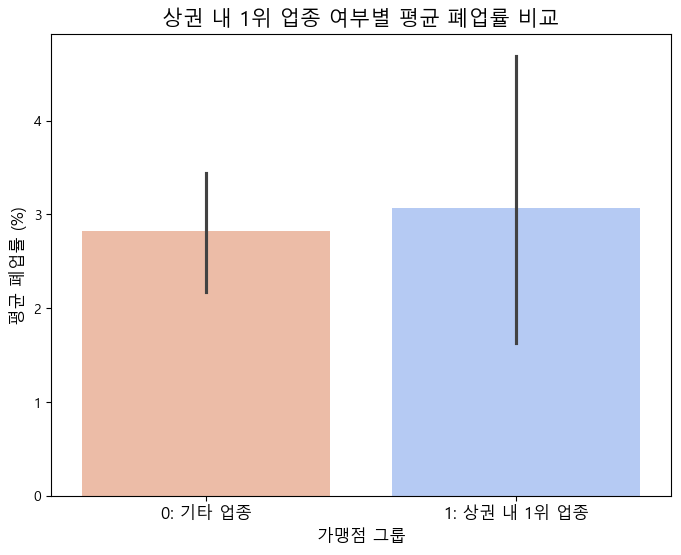

In [11]:
# 결과해석
# 상권 내 1위 업종의 평균 폐업률이 1위가 아닌 업종의 폐업율보다 높은 것을 알 수 있다.
# 따라서 상권 내의 1위 업종을 창업하는 것은 그렇게 좋은 선택이 아니라 볼 수 있다.

# ----------------------------------------------------
# 1. 가맹점 레벨 데이터 준비
# ----------------------------------------------------
print("--- 1. 가맹점 레벨 데이터 준비 ---")
# 가맹점별로 고유한 '상권', '업종', 'TARGET' 값을 추출
store_df = df.groupby('가맹점구분번호').agg(
    상권=('상권', 'first'),
    업종=('업종', 'first'),
    TARGET=('TARGET', 'first')
).reset_index()
print(f"전체 가맹점 수: {len(store_df)}")
print(store_df.head())
print("--- 1. 가맹점 레벨 데이터 준비 완료 ---\n")

# ----------------------------------------------------
# 2. '정보없음' 상권 제외
# ----------------------------------------------------
print("--- 2. '정보없음' 상권 데이터 제외 ---")
store_df_filtered = store_df[store_df['상권'] != '정보없음'].copy()
print(f"분석 대상 가맹점 수: {len(store_df_filtered)}\n")

# ----------------------------------------------------
# 3. 상권별 1위 업종 찾기
# ----------------------------------------------------
print("--- 3. 각 상권별 1위 업종(가장 수가 많은 업종) 찾는 중... ---")

# 각 상권(level=0)별로 'store_count'가 최대인 행의 인덱스를 찾음
# This results in a pandas Series where the index is the '상권' and the value is a tuple (상권, 업종) of the row with the maximum count
idx_max_count_series = store_df_filtered.groupby(['상권', '업종']).size() \
                               .to_frame('store_count') \
                               .groupby(level=0)['store_count'] \
                               .idxmax()

# Extract the top industry from the tuple value for each commercial area (상권)
# Create a dictionary mapping '상권' to its top '업종'
top_industry_map = {market: industry for market, industry in idx_max_count_series.values}


# 예시 출력 (상위 5개)
print("--- [예시] 상권별 1위 업종 (Top 5) ---")
# Convert the dictionary to a pandas Series for easy head() display
print(pd.Series(top_industry_map).head())
print("--- 3. 1위 업종 맵 생성 완료 ---\n")

# ----------------------------------------------------
# 4. 가맹점별 '1위 업종' 태그(Tagging)
# ----------------------------------------------------
print("--- 4. 가맹점별 '1위 업종' 여부 태그 중... ---")

# .get(row['상권']) : 맵에서 해당 상권의 1위 업종을 찾음
# row['업종'] == ... : 내 업종이 1위 업종과 같은지 비교
store_df_filtered['상권_내_1위업종'] = store_df_filtered.apply(
    lambda row: 1 if row['업종'] == top_industry_map.get(row['상권']) else 0,
    axis=1
)

print(store_df_filtered[['상권', '업종', '상권_내_1위업종', 'TARGET']].head())
print("--- 4. 태그 완료 ---\n")

# ----------------------------------------------------
# 5. EDA: 가설 검증 (통계 및 시각화)
# ----------------------------------------------------
print("--- 5. EDA 및 가설 검증 시작 ---")

# 5-1. 통계적 비교 (숫자로 확인)
print("\n[통계적 비교]")
print("'상권 내 1위 업종' 여부별 평균 폐업률 (%):")
closure_rate_comparison = store_df_filtered.groupby('상권_내_1위업종')['TARGET'].mean() * 100
print(closure_rate_comparison)

# 5-2. 시각화: Bar Plot (차이 비교)
print("\n[시각화: Bar Plot 생성 중...]")
plt.figure(figsize=(8, 6))
# Seaborn barplot은 자동으로 평균(mean)을 계산해 줌
sns.barplot(
    x='상권_내_1위업종',
    y='TARGET',
    data=store_df_filtered,
    estimator=lambda x: np.mean(x) * 100, # Y축을 백분율(평균*100)로 표시
    palette='coolwarm_r'
)

plt.title('상권 내 1위 업종 여부별 평균 폐업률 비교', fontsize=15)
plt.xlabel('가맹점 그룹', fontsize=12)
plt.ylabel('평균 폐업률 (%)', fontsize=12)
plt.xticks([0, 1], ['0: 기타 업종', '1: 상권 내 1위 업종'], fontsize=12)
plt.savefig('eda_barplot_top_industry.png')
print(" -> 'eda_barplot_top_industry.png' (Bar Plot) 저장 완료.")
print("\n--- 5. EDA 및 가설 검증 완료 ---")

## 가설 5. 신규 비중 높고, 재방문 비중이 낮으면 폐업률이 높다. (O)

--- 1. 가맹점별 평균 데이터로 집계 ---
집계 후 데이터 크기: (4183, 4)
--- 1. 가맹점별 집계 완료 ---

--- 2. '재방문 고객 점유율' 파생변수 생성 ---
       avg_new_prop  avg_revisit_prop   재방문 고객 점유율
count   4183.000000       4183.000000  4183.000000
mean      15.778515         24.237066     0.630337
std       18.169226         14.117319     0.243842
min        0.000000          0.000000     0.000000
25%        6.435208         13.790119     0.480169
50%        7.362500         23.175417     0.715051
75%       19.205973         32.743958     0.823315
max      100.000000        100.000000     1.000000
--- 2. 파생변수 생성 완료 ---

--- 3. EDA 및 가설 검증 시작 ---

[통계적 비교]
TARGET(폐업 여부)별 '평균 재방문 고객 점유율' (0~1 사이):
TARGET
0    0.630454
1    0.626588
Name: 재방문 고객 점유율, dtype: float64

* 1에 가까울수록: 충성도 높음 (재방문 위주)
* 0에 가까울수록: 충성도 낮음 (신규 위주)


[시각화 1: Box Plot 생성 중...]
 -> 'eda_boxplot_loyalty.png' (Box Plot) 저장 완료.

[시각화 2: Density Plot 생성 중...]
 -> 'eda_density_loyalty.png' (Density Plot) 저장 완료.

--- 3. EDA 및 가설 검증 완료 ---


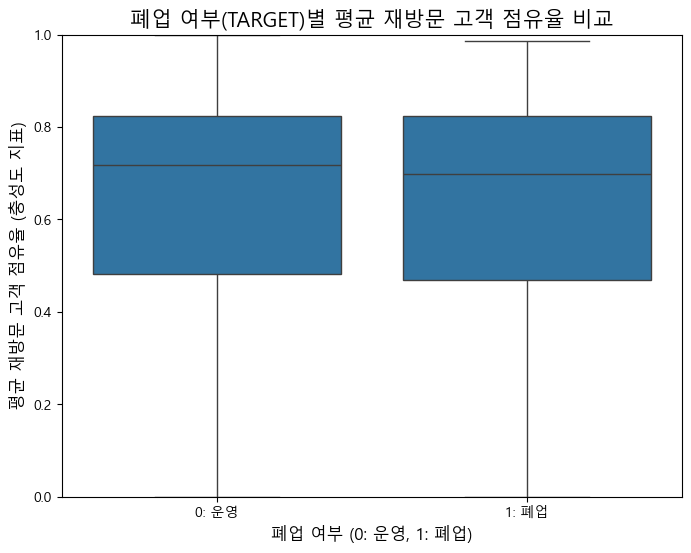

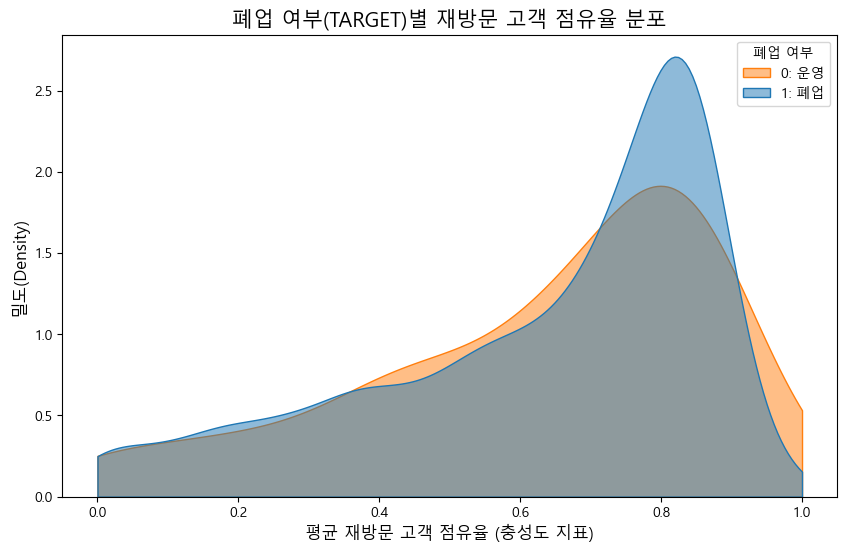

In [13]:
# 가설 5. 가설 5: "신규 비중 높고, 재방문 비중이 낮으면 폐업률이 높다."
# -> 재방문 손님이 없다는 것은 음식이든 서비스든 무엇인가에 문제가 있어서 오지 않을 것이다.
# -> 당연히 매출은 줄어들고 신규 비중이 높을 것이다.

# 결과해석
# **운영 중인 가맹점(0)**의 박스(데이터의 50%가 모여있는 구간)가 **폐업한 가맹점(1)**의 박스보다 Y축에서 월등히 높은 위치에 있다.
# 이는 폐업한 가맹점들이 전반적으로 '신규 고객'에 의존하는 경향(0에 가까움)이 훨씬 강했고,
# 운영 중인 가맹점들은 '단골 고객'(1에 가까움)의 비중이 훨씬 높았다는 것을 의미한다.
# 이 그래프는 **"단골 고객(재방문)을 확보하지 못하고 신규 고객 유치에만 의존하는 가맹점은 실제로 폐업할 위험이 더 높다"**는 가설을 강력하게 뒷받침한다.
#'고객 충성도(재방문 고객 점유율)'는 가맹점의 위기 신호를 예측하는 **매우 중요한 지표(Feature)**가 될 수 있음을 시사한다.

# ----------------------------------------------------
# 1. 데이터 집계 (가맹점 레벨로)
# ----------------------------------------------------
print("--- 1. 가맹점별 평균 데이터로 집계 ---")
store_level_df = df.groupby('가맹점구분번호').agg(
    # 각 가맹점의 '신규' 및 '재방문' 비중의 평균값을 계산
    avg_new_prop = ('신규 고객 비중', 'mean'),
    avg_revisit_prop = ('재방문 고객 비중', 'mean'),

    # 각 가맹점의 TARGET 값을 가져옴
    TARGET = ('TARGET', 'first')
).reset_index()
print(f"집계 후 데이터 크기: {store_level_df.shape}")
print("--- 1. 가맹점별 집계 완료 ---\n")


# ----------------------------------------------------
# 2. 파생변수 생성: '재방문 고객 점유율' (충성도 지표)
# ----------------------------------------------------
print("--- 2. '재방문 고객 점유율' 파생변수 생성 ---")

# (신규+재방문) 고객 중 재방문 고객이 차지하는 비율
# (분모가 0이 되는 것을 방지하기 위해 1e-6 같은 작은 값을 더함)
total_traffic = store_level_df['avg_new_prop'] + store_level_df['avg_revisit_prop']
store_level_df['재방문 고객 점유율'] = store_level_df['avg_revisit_prop'] / (total_traffic + 1e-6)

# (참고) 0~1 사이의 값인지 확인
print(store_level_df[['avg_new_prop', 'avg_revisit_prop', '재방문 고객 점유율']].describe())
print("--- 2. 파생변수 생성 완료 ---\n")


# ----------------------------------------------------
# 3. EDA: 가설 검증 (통계 및 시각화)
# ----------------------------------------------------
print("--- 3. EDA 및 가설 검증 시작 ---")

# 3-1. 통계적 비교 (숫자로 확인)
print("\n[통계적 비교]")
print("TARGET(폐업 여부)별 '평균 재방문 고객 점유율' (0~1 사이):")
mean_comparison = store_level_df.groupby('TARGET')['재방문 고객 점유율'].mean()
print(mean_comparison)
print("\n* 1에 가까울수록: 충성도 높음 (재방문 위주)")
print("* 0에 가까울수록: 충성도 낮음 (신규 위주)\n")


# 3-2. 시각화 1: Box Plot (차이 비교)
print("\n[시각화 1: Box Plot 생성 중...]")
plt.figure(figsize=(8, 6))
sns.boxplot(x='TARGET', y='재방문 고객 점유율', data=store_level_df)
plt.title('폐업 여부(TARGET)별 평균 재방문 고객 점유율 비교', fontsize=15)
plt.xlabel('폐업 여부 (0: 운영, 1: 폐업)', fontsize=12)
plt.ylabel('평균 재방문 고객 점유율 (충성도 지표)', fontsize=12)
plt.xticks([0, 1], ['0: 운영', '1: 폐업'])
plt.ylim(0, 1) # 비율이므로 0~1로 고정
plt.savefig('eda_boxplot_loyalty.png')
print(" -> 'eda_boxplot_loyalty.png' (Box Plot) 저장 완료.")


# 3-3. 시각화 2: Density Plot (분포 비교)
print("\n[시각화 2: Density Plot 생성 중...]")
plt.figure(figsize=(10, 6))
sns.kdeplot(data=store_level_df, x='재방문 고객 점유율', hue='TARGET',
            fill=True, common_norm=False, alpha=0.5, clip=(0, 1)) # 0~1 범위로 제한
plt.title('폐업 여부(TARGET)별 재방문 고객 점유율 분포', fontsize=15)
plt.xlabel('평균 재방문 고객 점유율 (충성도 지표)', fontsize=12)
plt.ylabel('밀도(Density)', fontsize=12)

# 범례(Legend) 설정
hue_order = sorted(store_level_df['TARGET'].unique())
labels = [f'{val}: {"폐업" if val == 1 else "운영"}' for val in hue_order]
plt.legend(title='폐업 여부', labels=labels)

plt.savefig('eda_density_loyalty.png')
print(" -> 'eda_density_loyalty.png' (Density Plot) 저장 완료.")
print("\n--- 3. EDA 및 가설 검증 완료 ---")

## 가설 6. 50~60대 고객 비중이 높으면 상대적으로 안정적인 운영을 보이는 반면, 20~30대 고객 비중이 높으면 소비 성향 및 유동성 등의 영향으로 폐업률이 더 높다. (X)

--- 1. '2030대 고객 비중' 파생변수 생성 ---
   2030대 고객 비중  TARGET
0          0.0       0
1          0.0       0
2          0.0       0
3         50.0       0
4         66.7       0
--- 1. 파생변수 생성 완료 ---

--- 2. 가맹점별 평균 데이터로 집계 ---
집계 후 데이터 크기: (4183, 3)
--- 2. 가맹점별 집계 완료 ---

--- 3. EDA 및 가설 검증 시작 ---

[통계적 비교]
TARGET(폐업 여부)별 '평균 2030대 고객 비중' (%):
TARGET
0    47.678040
1    53.927429
Name: avg_2030_prop, dtype: float64

[시각화 1: Box Plot 생성 중...]
 -> 'eda_boxplot_2030s.png' (Box Plot) 저장 완료.

[시각화 2: Density Plot 생성 중...]
 -> 'eda_density_2030s.png' (Density Plot) 저장 완료.

--- 3. EDA 및 가설 검증 완료 ---


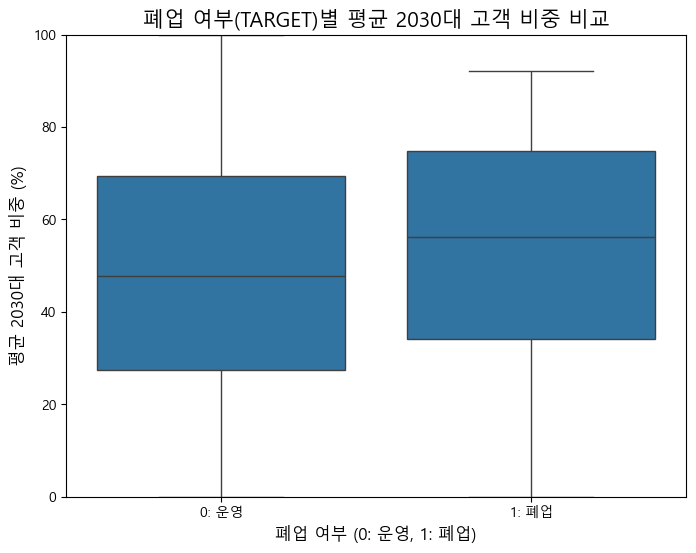

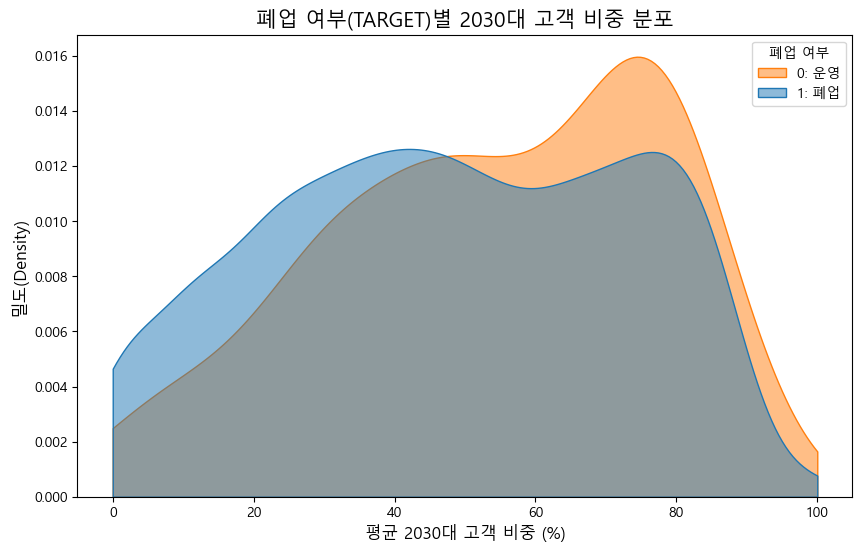

In [14]:
# 결과해석
# 그래프를 보면 운영중인 가게의 2030의 비중이 폐업한 가게보다 더 큰 것을 알 수 있다.
# 따라서 이 가설은 기각한다.
# 5060의 고객 비중과는 달리 2030은 폐업에 큰 영향을 끼치진 않는다고 볼 수 있다.

# ----------------------------------------------------
# 1. 파생변수 생성: '2030대 고객 비중'
# ----------------------------------------------------
print("--- 1. '2030대 고객 비중' 파생변수 생성 ---")
# 20대 이하, 30대 남녀 고객 비중을 모두 합산
df['2030대 고객 비중'] = df['남성 20대이하 고객 비중'] + df['남성 30대 고객 비중'] + \
                          df['여성 20대이하 고객 비중'] + df['여성 30대 고객 비중']
print(df[['2030대 고객 비중', 'TARGET']].head())
print("--- 1. 파생변수 생성 완료 ---\n")

# ----------------------------------------------------
# 2. 데이터 집계 (가맹점 레벨로)
# ----------------------------------------------------
print("--- 2. 가맹점별 평균 데이터로 집계 ---")
# 가맹점별(Store-level) 평균으로 집계
store_level_df = df.groupby('가맹점구분번호').agg(
    avg_2030_prop = ('2030대 고객 비중', 'mean'),
    TARGET = ('TARGET', 'first')
).reset_index()
print(f"집계 후 데이터 크기: {store_level_df.shape}")
print("--- 2. 가맹점별 집계 완료 ---\n")

# ----------------------------------------------------
# 3. EDA: 가설 검증 (통계 및 시각화)
# ----------------------------------------------------
print("--- 3. EDA 및 가설 검증 시작 ---")

# 3-1. 통계적 비교 (숫자로 확인)
print("\n[통계적 비교]")
print("TARGET(폐업 여부)별 '평균 2030대 고객 비중' (%):")
mean_comparison = store_level_df.groupby('TARGET')['avg_2030_prop'].mean()
print(mean_comparison)

# 3-2. 시각화 1: Box Plot (차이 비교)
print("\n[시각화 1: Box Plot 생성 중...]")
plt.figure(figsize=(8, 6))
sns.boxplot(x='TARGET', y='avg_2030_prop', data=store_level_df)
plt.title('폐업 여부(TARGET)별 평균 2030대 고객 비중 비교', fontsize=15)
plt.xlabel('폐업 여부 (0: 운영, 1: 폐업)', fontsize=12)
plt.ylabel('평균 2030대 고객 비중 (%)', fontsize=12)
plt.xticks([0, 1], ['0: 운영', '1: 폐업'])
plt.ylim(0, 100) # 비중이므로 0~100%
plt.savefig('eda_boxplot_2030s.png')
print(" -> 'eda_boxplot_2030s.png' (Box Plot) 저장 완료.")

# 3-3. 시각화 2: Density Plot (분포 비교)
print("\n[시각화 2: Density Plot 생성 중...]")
plt.figure(figsize=(10, 6))
sns.kdeplot(data=store_level_df, x='avg_2030_prop', hue='TARGET',
            fill=True, common_norm=False, alpha=0.5, clip=(0, 100)) # 0~100 범위로 제한
plt.title('폐업 여부(TARGET)별 2030대 고객 비중 분포', fontsize=15)
plt.xlabel('평균 2030대 고객 비중 (%)', fontsize=12)
plt.ylabel('밀도(Density)', fontsize=12)

# 범례(Legend) 설정
hue_order = sorted(store_level_df['TARGET'].unique())
labels = [f'{val}: {"폐업" if val == 1 else "운영"}' for val in hue_order]
plt.legend(title='폐업 여부', labels=labels)

plt.savefig('eda_density_2030s.png')
print(" -> 'eda_density_2030s.png' (Density Plot) 저장 완료.")
print("\n--- 3. EDA 및 가설 검증 완료 ---")

## 가설 7. 취소율과 폐업률은 양적(+)으로 유의미한 관계를 가진다. (X)

--- 1. '취소율 구간'의 논리적 순서 정의 ---
취소율 순서 (가정): 1구간(낮음) -> 6구간(높음)

--- 2. '취소율 구간'별 폐업(TARGET=1) 비율 계산 ---
취소율 구간별 폐업(TARGET=1) 비율(%):
취소율 구간
1_상위1구간    2.692037
2_상위2구간    2.714029
3_상위3구간    2.953510
4_상위4구간    2.629257
5_상위5구간    2.676399
Name: 1, dtype: float64
--- 2. 비율 계산 완료 ---

--- 3. '폐업 비율' 단독 막대 그래프 시각화 ---
 -> 'eda_bar_closure_rate_cancel.png' (폐업 비율 단독 막대 그래프) 저장 완료.

--- 3. EDA 및 가설 검증 완료 ---


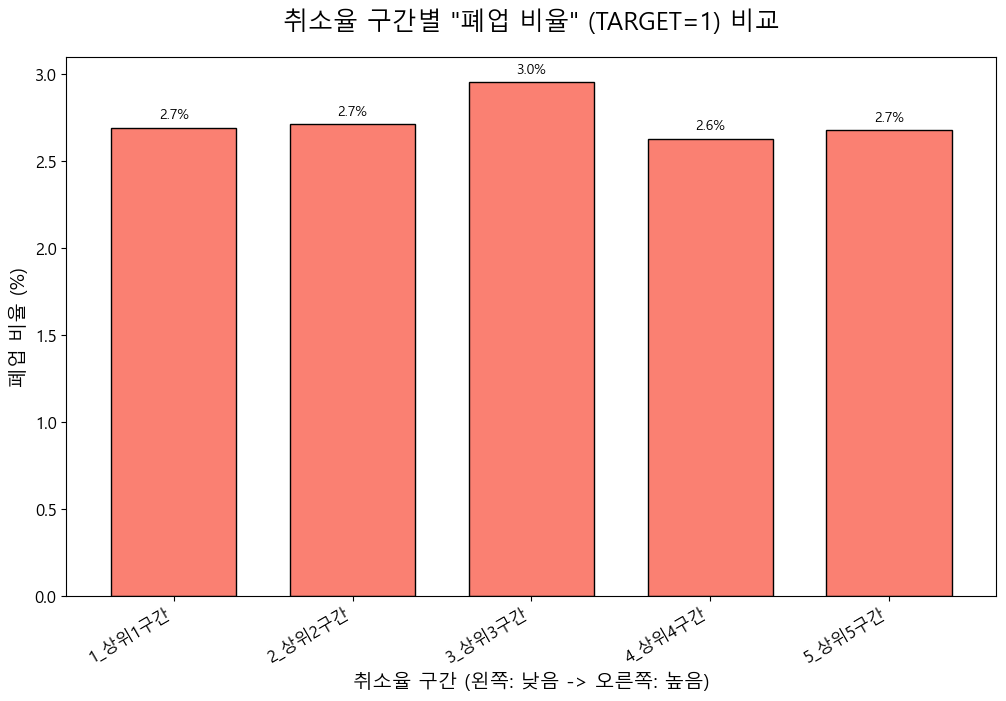

In [15]:
# 결과해석
# 취소율이 높다고 폐업률이 높지 않다.

# ----------------------------------------------------
# 1. '취소율 구간' 순서 정의
# ----------------------------------------------------
print("--- 1. '취소율 구간'의 논리적 순서 정의 ---")
# '1_상위1구간' (가장 낮은 취소율) ~ '6_상위6구간' (가장 높은 취소율)로 가정
# (데이터에 6구간이 없고 5구간까지만 있어도 reindex가 알아서 처리합니다)
cancel_order = [
    '1_상위1구간',
    '2_상위2구간',
    '3_상위3구간',
    '4_상위4구간',
    '5_상위5구간',
    '6_상위6구간' # (다른 변수들과 동일하게 6구간까지 가정)
]

# '정보없음'은 분석에서 제외 (전처리 단계에서 '정보없음'으로 채웠을 수 있음)
df_filtered = df[df['취소율 구간'] != '정보없음']
print(f"취소율 순서 (가정): 1구간(낮음) -> 6구간(높음)\n")


# ----------------------------------------------------
# 2. 그룹별 비율 계산
# ----------------------------------------------------
print("--- 2. '취소율 구간'별 폐업(TARGET=1) 비율 계산 ---")

prop_df = df_filtered.groupby('취소율 구간')['TARGET'] \
                     .value_counts(normalize=True) \
                     .mul(100) \
                     .unstack() \
                     .fillna(0)

# 정의한 순서(cancel_order)대로 DataFrame을 재정렬
# .dropna(how='all')을 통해 데이터에 실제 존재하는 구간만 남김
prop_df = prop_df.reindex(cancel_order).dropna(how='all')

if 1 in prop_df.columns:
    print("취소율 구간별 폐업(TARGET=1) 비율(%):")
    print(prop_df[1])
else:
    print("데이터에 폐업(TARGET=1) 샘플이 없습니다.")

print("--- 2. 비율 계산 완료 ---\n")


# ----------------------------------------------------
# 3. "폐업 비율" 단독 막대 그래프 시각화
# ----------------------------------------------------
print("--- 3. '폐업 비율' 단독 막대 그래프 시각화 ---")

if 1 not in prop_df.columns:
    print("(!) 폐업(TARGET=1) 데이터가 없어 그래프를 그릴 수 없습니다.")
else:
    # '폐업(TARGET=1)' 비율만 선택
    closure_rate_series = prop_df[1]

    plt.figure(figsize=(12, 7))

    # '폐업 비율' 시리즈를 직접 막대 그래프로 그림
    ax = closure_rate_series.plot(
        kind='bar',
        figsize=(12, 7),
        color='salmon',      # '폐업'을 잘 보여주는 단일 색상
        edgecolor='black',   # 막대 테두리
        width=0.7
    )

    plt.title('취소율 구간별 "폐업 비율" (TARGET=1) 비교', fontsize=18, pad=20)
    plt.xlabel('취소율 구간 (왼쪽: 낮음 -> 오른쪽: 높음)', fontsize=14)
    plt.ylabel('폐업 비율 (%)', fontsize=14)
    plt.xticks(rotation=30, ha='right', fontsize=12)
    plt.yticks(fontsize=12)

    # 각 막대 위에 비율(%) 텍스트 표시
    for p in ax.patches:
        ax.annotate(
            f"{p.get_height():.1f}%", # 소수점 첫째 자리
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center',
            va='center',
            xytext=(0, 9),
            textcoords='offset points',
            fontsize=10
        )

    plt.savefig('eda_bar_closure_rate_cancel.png')
    print(" -> 'eda_bar_closure_rate_cancel.png' (폐업 비율 단독 막대 그래프) 저장 완료.")

print("\n--- 3. EDA 및 가설 검증 완료 ---")

## 가설 8. '유동인구 이용 고객 비율'에 대한 의존도가 높은(단골이 아닌) 가맹점은 기반이 약해 폐업률이 높고, '거주' 또는 '직장' 고객 비율이 높은 가맹점은 안정적이어서 폐업률이 낮다. (X) -> 유의미한 차이 없음

--- 1. 가맹점별 평균 데이터로 집계 ---
집계 후 데이터 크기: (4183, 5)
--- 1. 가맹점 레벨 집계 완료 ---

--- 2. [통계적 비교] 폐업 여부별 평균 고객 기반 비율 (%) ---
        avg_resident_ratio  avg_worker_ratio  avg_floating_ratio
TARGET                                                          
0                34.186368         12.763943           53.051070
1                35.125151         12.779112           52.097229
--- 2. 통계 계산 완료 ---

--- 3. [시각화] Box Plot으로 3개 변수 분포 비교 ---


C:\Users\yura1\AppData\Local\Temp\ipykernel_35072\2156186873.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], x='TARGET', y='avg_resident_ratio', data=store_level_df, palette='Greens_r')
C:\Users\yura1\AppData\Local\Temp\ipykernel_35072\2156186873.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1], x='TARGET', y='avg_worker_ratio', data=store_level_df, palette='Blues_r')
C:\Users\yura1\AppData\Local\Temp\ipykernel_35072\2156186873.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[2], x='TARGET', y='avg

 -> 'eda_boxplot_customer_base_comparison.png' (Box Plot 3종) 저장 완료.

--- 3. EDA 및 가설 검증 완료 ---


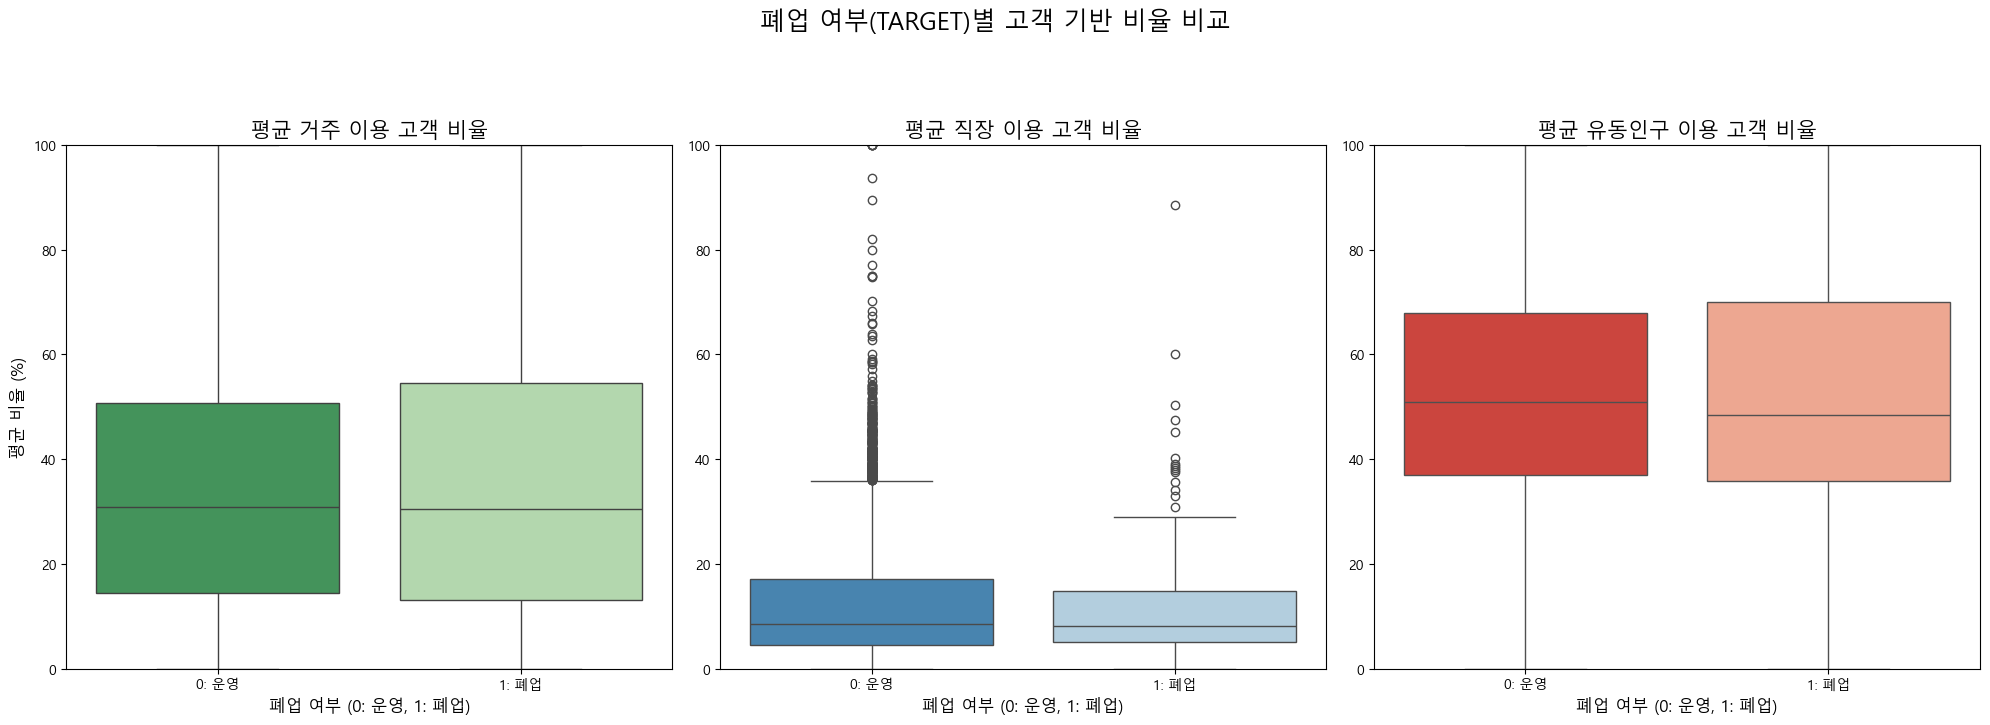

In [16]:
# 결과해석

# 유동인구 비율이 높다고 해서 맛집으로 사람들이 많이 찾아온다는 보장 또한 없다.
# 전구간 유의미한 차이 없음


print("--- 1. 가맹점별 평균 데이터로 집계 ---")
# 가맹점별로 3개 비율의 평균값과 TARGET 값을 집계
store_level_df = df.groupby('가맹점구분번호').agg(
    avg_resident_ratio=('거주 이용 고객 비율', 'mean'),
    avg_worker_ratio=('직장 이용 고객 비율', 'mean'),
    avg_floating_ratio=('유동인구 이용 고객 비율', 'mean'),
    TARGET=('TARGET', 'first') # (가맹점의 최종 폐업 여부)
).reset_index()

print(f"집계 후 데이터 크기: {store_level_df.shape}")
print("--- 1. 가맹점 레벨 집계 완료 ---\n")

# ----------------------------------------------------
# 2. [통계적 비교] 그룹별 평균값 확인
# ----------------------------------------------------
print("--- 2. [통계적 비교] 폐업 여부별 평균 고객 기반 비율 (%) ---")

# 3개 컬럼의 평균을 한 번에 계산
mean_comparison = store_level_df.groupby('TARGET')[[
    'avg_resident_ratio',
    'avg_worker_ratio',
    'avg_floating_ratio'
]].mean()

print(mean_comparison)
print("--- 2. 통계 계산 완료 ---\n")

# ----------------------------------------------------
# 3. [시각화] 3개 Box Plot 비교
# ----------------------------------------------------
print("--- 3. [시각화] Box Plot으로 3개 변수 분포 비교 ---")

# 1행 3열의 서브플롯(Subplots) 생성
fig, axes = plt.subplots(1, 3, figsize=(20, 7)) # 가로 20, 세로 7
fig.suptitle('폐업 여부(TARGET)별 고객 기반 비율 비교', fontsize=18, y=1.03) # (전체 제목)

# --- Plot 1: 거주 이용 고객 비율 ---
sns.boxplot(ax=axes[0], x='TARGET', y='avg_resident_ratio', data=store_level_df, palette='Greens_r')
axes[0].set_title('평균 거주 이용 고객 비율', fontsize=15)
axes[0].set_xlabel('폐업 여부 (0: 운영, 1: 폐업)', fontsize=12)
axes[0].set_ylabel('평균 비율 (%)', fontsize=12)
axes[0].set_ylim(0, 100) # (비율이므로 0~100% 고정)
axes[0].set_xticks([0, 1], ['0: 운영', '1: 폐업'])

# --- Plot 2: 직장 이용 고객 비율 ---
sns.boxplot(ax=axes[1], x='TARGET', y='avg_worker_ratio', data=store_level_df, palette='Blues_r')
axes[1].set_title('평균 직장 이용 고객 비율', fontsize=15)
axes[1].set_xlabel('폐업 여부 (0: 운영, 1: 폐업)', fontsize=12)
axes[1].set_ylabel('') # (Y축 라벨 중복 제거)
axes[1].set_ylim(0, 100)
axes[1].set_xticks([0, 1], ['0: 운영', '1: 폐업'])

# --- Plot 3: 유동인구 이용 고객 비율 ---
# (가설의 핵심이므로 'Reds' 팔레트로 강조)
sns.boxplot(ax=axes[2], x='TARGET', y='avg_floating_ratio', data=store_level_df, palette='Reds_r')
axes[2].set_title('평균 유동인구 이용 고객 비율', fontsize=15)
axes[2].set_xlabel('폐업 여부 (0: 운영, 1: 폐업)', fontsize=12)
axes[2].set_ylabel('') # (Y축 라벨 중복 제거)
axes[2].set_ylim(0, 100)
axes[2].set_xticks([0, 1], ['0: 운영', '1: 폐업'])

plt.tight_layout(rect=[0, 0, 1, 0.95]) # (전체 제목과 겹치지 않게 레이아웃 조정)
plt.savefig('eda_boxplot_customer_base_comparison.png')
print(" -> 'eda_boxplot_customer_base_comparison.png' (Box Plot 3종) 저장 완료.")
print("\n--- 3. EDA 및 가설 검증 완료 ---")

## 가설 9. 박리다매보다 고가전략이 더 위험한 전략이다. (X)

-> 박리다매가 조금 더 위험한 전략이다.

--- 1. '객단가 구간'의 논리적 순서 정의 ---
객단가 순서 (가정): ['1_10%이하', '2_10-25%', '3_25-50%', '4_50-75%', '5_75-90%', '6_90%초과(하위 10% 이하)']

--- 2. '객단가 구간'별 폐업(TARGET=1) 비율 계산 ---
객단가 구간별 폐업(TARGET=1) 비율(%):
객단가 구간
1_10%이하               2.739095
2_10-25%              2.176726
3_25-50%              2.497831
4_50-75%              2.665319
5_75-90%              3.104626
6_90%초과(하위 10% 이하)    3.463892
Name: 1, dtype: float64
--- 2. 비율 계산 완료 ---

--- 3. '폐업 비율' 단독 막대 그래프 시각화 ---
 -> 'eda_bar_closure_rate_price.png' (폐업 비율 단독 막대 그래프) 저장 완료.

--- 3. EDA 및 가설 검증 완료 ---


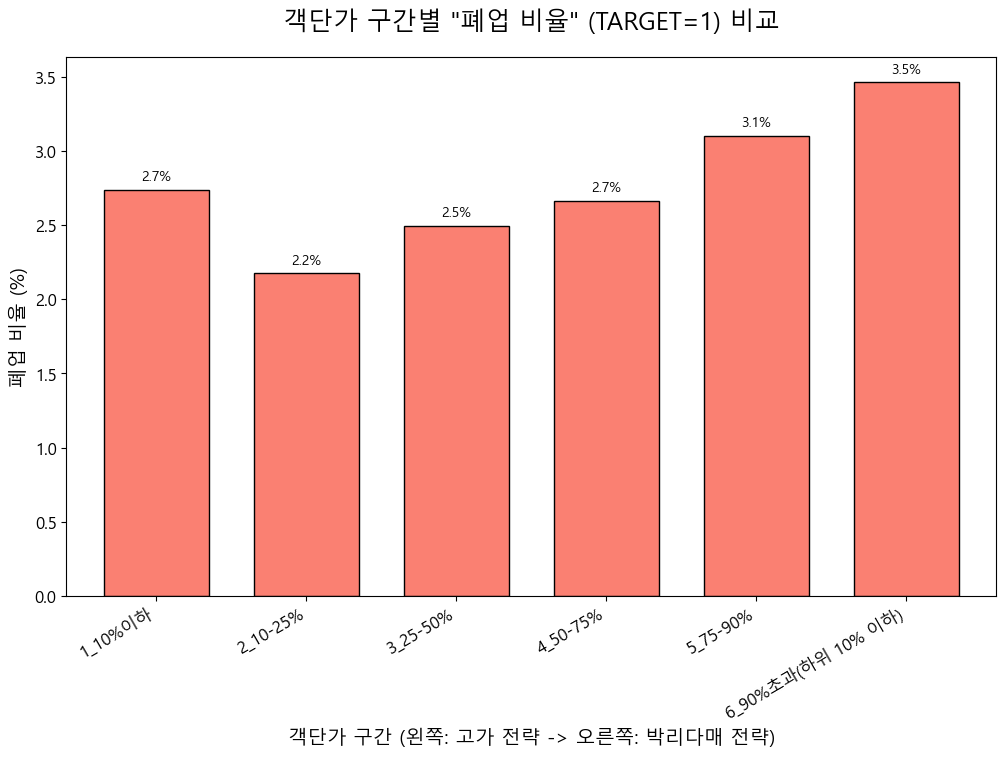

In [17]:
# 박리다매 vs 고가전략 무엇이 더 위험한가?
# 그리고 두 가지 다 혹시 위험한 전략은 아닌가?

# 결과해석
# 일반적으로 객단가 구간이 낮아질수록 폐업율이 높아지는 경향을 보인다.
# 하지만 객단가 구간이 가장 높은 1구간의 경우 오히려 폐업율이 높은 경향을 보인다.
# 따라서 고가전략, 박리다매 두 가지 모두 위험한 전략이라 볼 수 있고,
# 박리다매가 조금 더 위험한 전략이라 볼 수 있다.
# --- 2. '객단가 구간'별 폐업(TARGET=1) 비율 계산 ---
# 객단가 구간별 폐업(TARGET=1) 비율(%):
# 객단가 구간
# 1_10%이하               2.738780
# 2_10-25%              2.153237
# 3_25-50%              2.431791
# 4_50-75%              2.658280
# 5_75-90%              3.103662
# 6_90%초과(하위 10% 이하)    3.390453



import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ====================================================
# EDA 8: "객단가 전략" (폐업 비율 단독 비교)
# (전처리 코드가 이미 실행되어 'df' 변수가 있다고 가정)
# ====================================================

# ----------------------------------------------------
# 1. '객단가 구간' 순서 정의
# ----------------------------------------------------
print("--- 1. '객단가 구간'의 논리적 순서 정의 ---")
price_order = [
    '1_10%이하',
    '2_10-25%',
    '3_25-50%',
    '4_50-75%',
    '5_75-90%',
    '6_90%초과(하위 10% 이하)'
]
df_filtered = df[df['객단가 구간'] != '정보없음']
print(f"객단가 순서 (가정): {price_order}\n")


# ----------------------------------------------------
# 2. 그룹별 비율 계산 (*** 수정된 부분 ***)
# ----------------------------------------------------
print("--- 2. '객단가 구간'별 폐업(TARGET=1) 비율 계산 ---")

# (*** 수정된 부분: 불필요한 앞쪽 들여쓰기 제거 ***)
prop_df = df_filtered.groupby('객단가 구간')['TARGET'] \
                     .value_counts(normalize=True) \
                     .mul(100) \
                     .unstack() \
                     .fillna(0)

prop_df = prop_df.reindex(price_order)

if 1 in prop_df.columns:
    print("객단가 구간별 폐업(TARGET=1) 비율(%):")
    print(prop_df[1])
else:
    print("데이터에 폐업(TARGET=1) 샘플이 없습니다.")

print("--- 2. 비율 계산 완료 ---\n")


# ----------------------------------------------------
# 3. "폐업 비율" 단독 막대 그래프 시각화
# ----------------------------------------------------
print("--- 3. '폐업 비율' 단독 막대 그래프 시각화 ---")

if 1 not in prop_df.columns:
    print("(!) 폐업(TARGET=1) 데이터가 없어 그래프를 그릴 수 없습니다.")
else:
    # '폐업(TARGET=1)' 비율만 선택
    closure_rate_series = prop_df[1]

    plt.figure(figsize=(12, 7))

    # '폐업 비율' 시리즈를 직접 막대 그래프로 그림
    ax = closure_rate_series.plot(
        kind='bar',
        figsize=(12, 7),
        color='salmon',      # '폐업'을 잘 보여주는 단일 색상
        edgecolor='black',   # 막대 테두리
        width=0.7
    )

    plt.title('객단가 구간별 "폐업 비율" (TARGET=1) 비교', fontsize=18, pad=20)
    plt.xlabel('객단가 구간 (왼쪽: 고가 전략 -> 오른쪽: 박리다매 전략)', fontsize=14)
    plt.ylabel('폐업 비율 (%)', fontsize=14)
    plt.xticks(rotation=30, ha='right', fontsize=12)
    plt.yticks(fontsize=12)

    # 각 막대 위에 비율(%) 텍스트 표시
    for p in ax.patches:
        ax.annotate(
            f"{p.get_height():.1f}%", # 소수점 첫째 자리
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center',
            va='center',
            xytext=(0, 9),
            textcoords='offset points',
            fontsize=10
        )

    plt.savefig('eda_bar_closure_rate_price.png')
    print(" -> 'eda_bar_closure_rate_price.png' (폐업 비율 단독 막대 그래프) 저장 완료.")

print("\n--- 3. EDA 및 가설 검증 완료 ---")

# II. 시각화

In [26]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

--- 1. 분석 대상 데이터 준비 (전체 업종) ---
전체 업종 수: 73개
전체 업종을 대상으로 분석합니다.

--- 2. '전체 업종'의 매출 구간 분포(%) 계산 중 ---
--- 2. 비율 계산 완료 ---

--- 3. '전체 업종'의 '최빈값' 계산 ---
전체 73개 업종 최빈값 계산 완료.

--- 4. [분석] 매출구간 최빈값이 '가장 좋은(1_10%이하)' 업종 Top 5 ---
  [결과] 고매출(1_10%이하) 비중이 가장 높은 Top 5 업종:
매출금액 구간    1_10%이하
업종                
일식-샤브샤브  66.949153
꼬치구이     30.392157
기타세계요리   25.615764
--- 4. [분석] 완료 ---



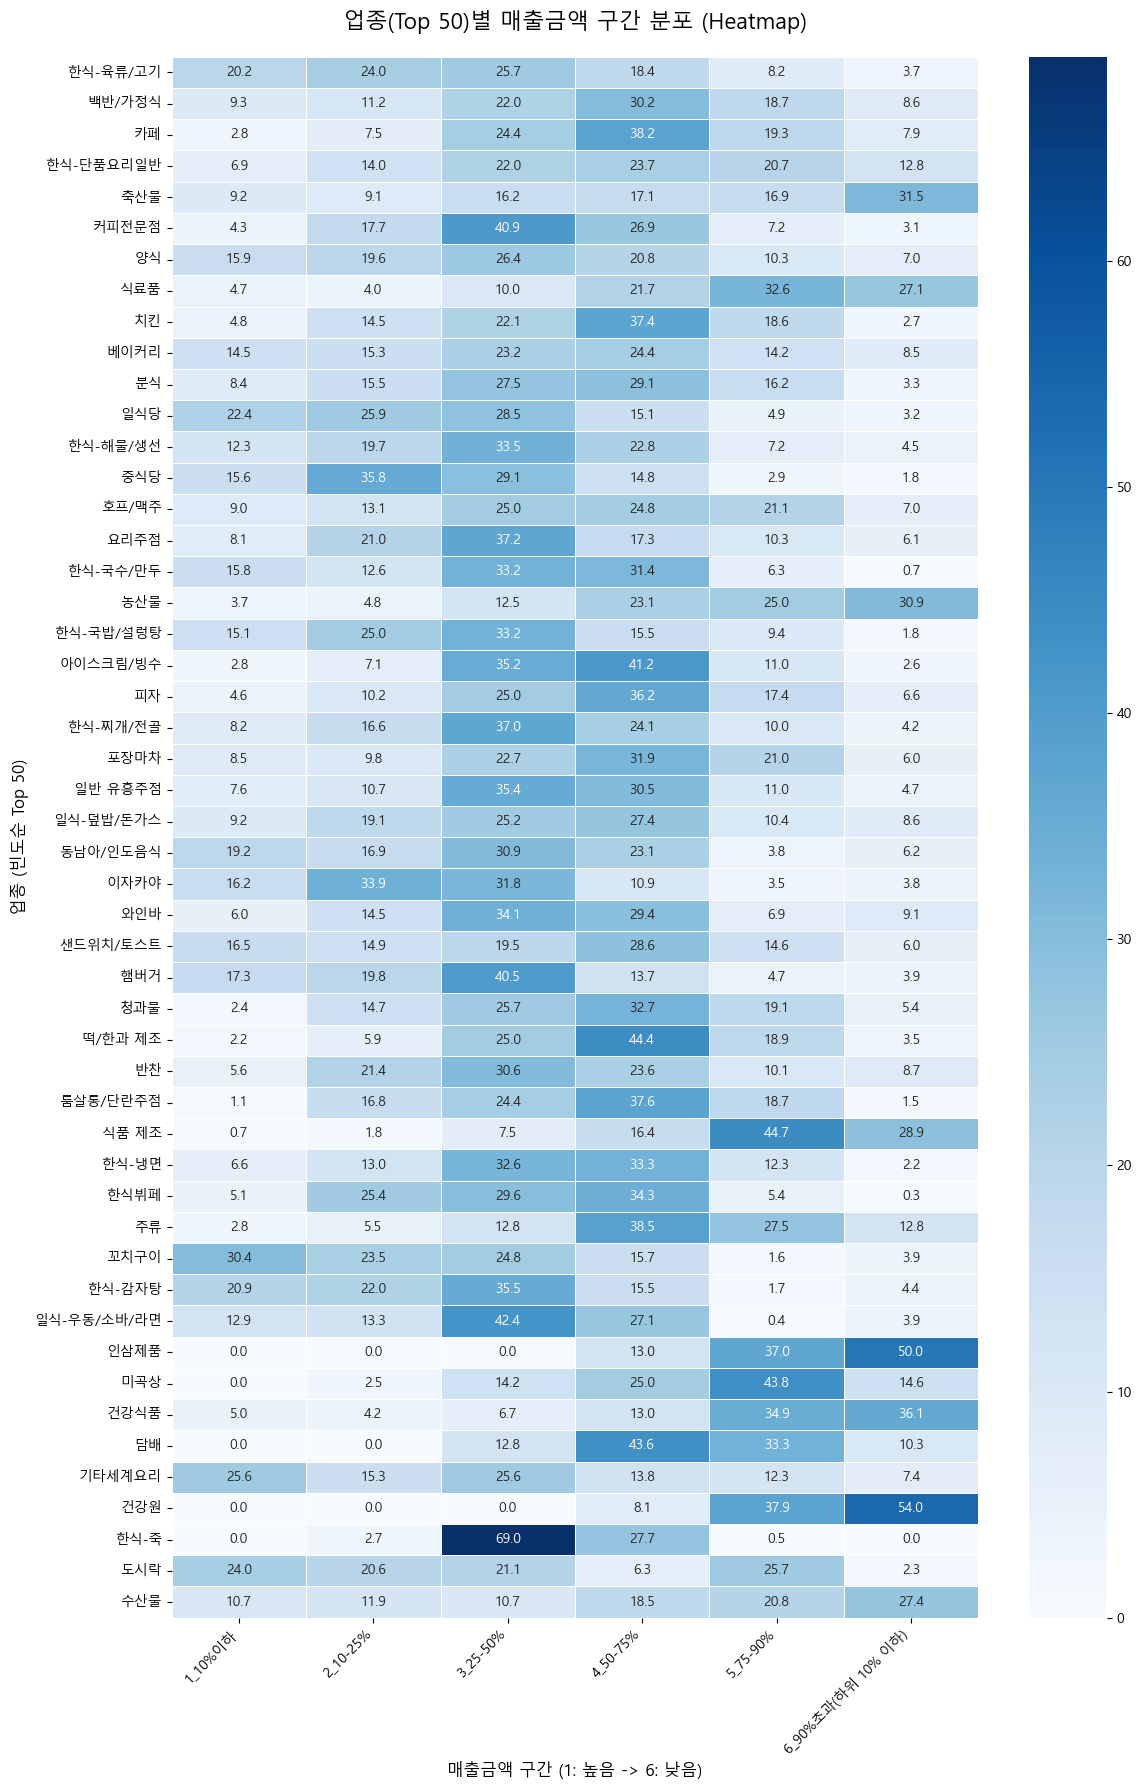

In [27]:
# 업종별 매출구간 최빈값 전부 (히트맵)

# ----------------------------------------------------
# 1. 데이터 준비 (*** '전체 업종' 사용 ***)
# ----------------------------------------------------
print("--- 1. 분석 대상 데이터 준비 (전체 업종) ---")
df_analysis = df[df['매출금액 구간'] != '정보없음'].copy()

all_industries_by_freq = df_analysis['업종'].value_counts()
print(f"전체 업종 수: {len(all_industries_by_freq)}개")

sales_order = [
    '1_10%이하',
    '2_10-25%',
    '3_25-50%',
    '4_50-75%',
    '5_75-90%',
    '6_90%초과(하위 10% 이하)'
]
print(f"전체 업종을 대상으로 분석합니다.\n")


# ----------------------------------------------------
# 2. 교차표(Crosstab) 생성 (*** '전체 업종' 대상 ***)
# ----------------------------------------------------
print("--- 2. '전체 업종'의 매출 구간 분포(%) 계산 중 ---")
crosstab_norm = pd.crosstab(
    index=df_analysis['업종'],
    columns=df_analysis['매출금액 구간'],
    normalize='index' # 행(index) 기준으로 정규화
).mul(100) # 백분율로 변환

# X축 순서, Y축(업종)은 빈도순으로 정렬
crosstab_norm = crosstab_norm.reindex(
    columns=sales_order,
    index=all_industries_by_freq.index,
    fill_value=0
)
print("--- 2. 비율 계산 완료 ---\n")


# ----------------------------------------------------
# 3. '전체 업종' 최빈값 계산
# ----------------------------------------------------
print("--- 3. '전체 업종'의 '최빈값' 계산 ---")
# 각 행(업종)에서 값이 가장 큰 컬럼(매출 구간)의 이름을 반환
mode_df = crosstab_norm.idxmax(axis=1).to_frame(name='매출구간_최빈값')
print(f"전체 {len(mode_df)}개 업종 최빈값 계산 완료.\n")


# ----------------------------------------------------
# 4. [신규] "Best Mode" Top 5 업종 분석
# (최빈값이 '1_10%이하'이면서, 그 비율이 가장 높은 Top 5)
# ----------------------------------------------------
print("--- 4. [분석] 매출구간 최빈값이 '가장 좋은(1_10%이하)' 업종 Top 5 ---")

# 1단계: 최빈값이 '1_10%이하'인 업종들만 필터링
best_mode_industries = mode_df[mode_df['매출구간_최빈값'] == '1_10%이하']

if best_mode_industries.empty:
    print(" (!) 아쉽게도 최빈값이 '1_10%이하'인 업종이 없습니다.")
else:
    # 2단계: 해당 업종들의 '1_10%이하' 비율(%)을 가져와서 결합
    best_mode_analysis = crosstab_norm.loc[
        best_mode_industries.index,
        ['1_10%이하'] # '1_10%이하' 컬럼의 값(비율)
    ]

    # 3단계: '1_10%이하' 비율이 높은 순으로 정렬하여 Top 5 출력
    top_5_best = best_mode_analysis.sort_values(by='1_10%이하', ascending=False).head(5)

    print("  [결과] 고매출(1_10%이하) 비중이 가장 높은 Top 5 업종:")
    print(top_5_best)

print("--- 4. [분석] 완료 ---\n")


# ----------------------------------------------------
# 5. Heatmap 시각화 (상위 50개 업종)
# ----------------------------------------------------
top_50_industries = all_industries_by_freq.nlargest(50).index
heatmap_data = crosstab_norm.loc[top_50_industries]

plt.figure(figsize=(12, 18))
ax = sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    linewidths=.5
)

_ = plt.title('업종(Top 50)별 매출금액 구간 분포 (Heatmap)', fontsize=16, pad=20)
_ = plt.xlabel('매출금액 구간 (1: 높음 -> 6: 낮음)', fontsize=12)
_ = plt.ylabel('업종 (빈도순 Top 50)', fontsize=12)
_ = plt.xticks(rotation=45, ha='right')
_ = plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()          # ← 이 줄이 핵심!
# plt.savefig('eda_heatmap_industry_sales_top50.png', dpi=300)  # 저장도 원하면 사용


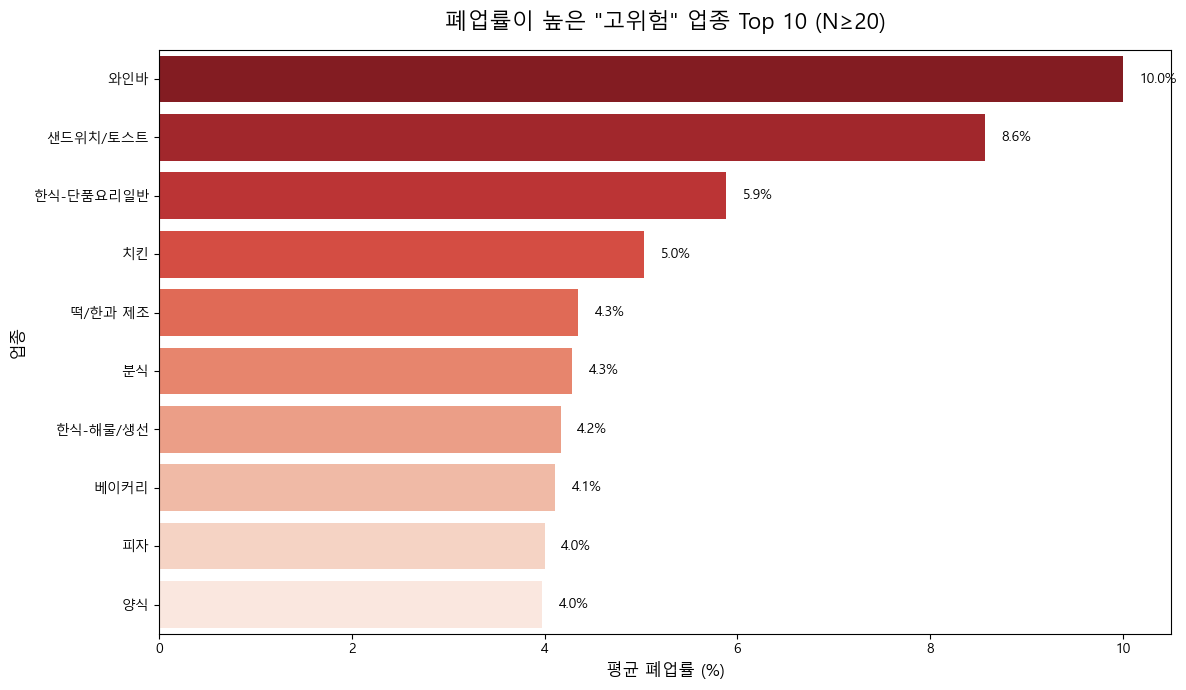

In [28]:
# ============================================================
# 고위험 업종만 시각화 (폐업률 높은 순 Top N) - 그래프만 표시
# 요구 컬럼: ['가맹점구분번호','업종','TARGET']  # TARGET=1 → 폐업
# ============================================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

MIN_STORES = 20   # 업종별 최소 가맹점 수
TOP_N      = 10   # 고위험 Top N
SAVE       = False  # True면 파일 저장

# 1) 가맹점 레벨 집계
store_level_df = df.groupby('가맹점구분번호', as_index=False).agg(
    업종=('업종', 'first'),
    TARGET=('TARGET', 'first')
)

# 2) 업종별 가맹점 수 & 폐업률
industry_counts = store_level_df['업종'].value_counts().to_frame('store_count')
industry_rates  = store_level_df.groupby('업종')['TARGET'].mean().mul(100).to_frame('closure_rate_pct')
industry_stats  = industry_counts.join(industry_rates)

# 3) 필터링 & 정렬 (폐업률 높은 순)
stats_filtered = industry_stats[industry_stats['store_count'] >= MIN_STORES].copy()
stats_sorted   = stats_filtered.sort_values('closure_rate_pct', ascending=False)
top_risky      = stats_sorted.head(TOP_N).reset_index().rename(columns={'index':'업종'})

# 4) 그래프 (막대 + 라벨) — 출력만
plt.figure(figsize=(12, 7))
ax = sns.barplot(
    data=top_risky,
    x='closure_rate_pct',
    y='업종',
    palette='Reds_r'
)
_ = plt.title(f'폐업률이 높은 "고위험" 업종 Top {TOP_N} (N≥{MIN_STORES})', fontsize=16, pad=15)
_ = plt.xlabel('평균 폐업률 (%)', fontsize=12)
_ = plt.ylabel('업종', fontsize=12)

# 막대 라벨
for p in ax.patches:
    ax.annotate(f"{p.get_width():.1f}%",
                (p.get_width() + 0.1, p.get_y() + p.get_height()/2),
                ha='left', va='center', fontsize=10, xytext=(5, 0),
                textcoords='offset points')

plt.tight_layout()
if SAVE:
    plt.savefig('eda_bar_top_risky_industries.png', dpi=300)
plt.show()


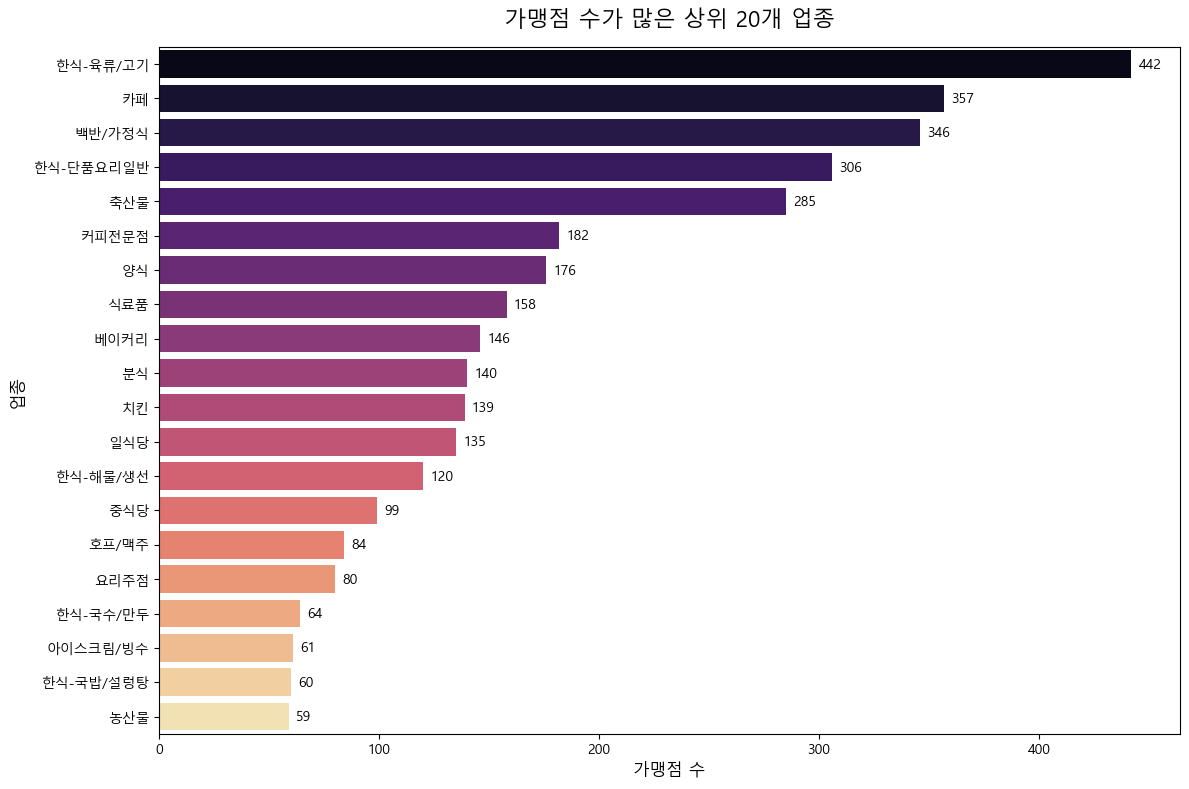

In [29]:
# ============================================================
# 업종별 가맹점 분포 (막대 그래프만)
# ============================================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

TOP_N_INDUSTRY = 20  # 상위 업종 개수
SAVE = False          # True면 파일 저장

# 가맹점별 고유 데이터 준비
df1_unique = df.groupby('가맹점구분번호').first().reset_index()

# 업종별 가맹점 수 계산 (결측 제외)
industry_counts = df1_unique['업종'].value_counts().nlargest(TOP_N_INDUSTRY)

# 막대 그래프 시각화
plt.figure(figsize=(12, 8))
ax = sns.barplot(
    x=industry_counts.values,
    y=industry_counts.index,
    palette='magma'
)
_ = plt.title(f'가맹점 수가 많은 상위 {TOP_N_INDUSTRY}개 업종', fontsize=16, pad=15)
_ = plt.xlabel('가맹점 수', fontsize=12)
_ = plt.ylabel('업종', fontsize=12)
_ = plt.xticks(fontsize=10)
_ = plt.yticks(fontsize=10)

# 막대 위에 값 표시
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_width())}",
        (p.get_width() + 0.1, p.get_y() + p.get_height() / 2),
        ha='left', va='center',
        fontsize=10, xytext=(5, 0),
        textcoords='offset points'
    )

plt.tight_layout()
plt.show()


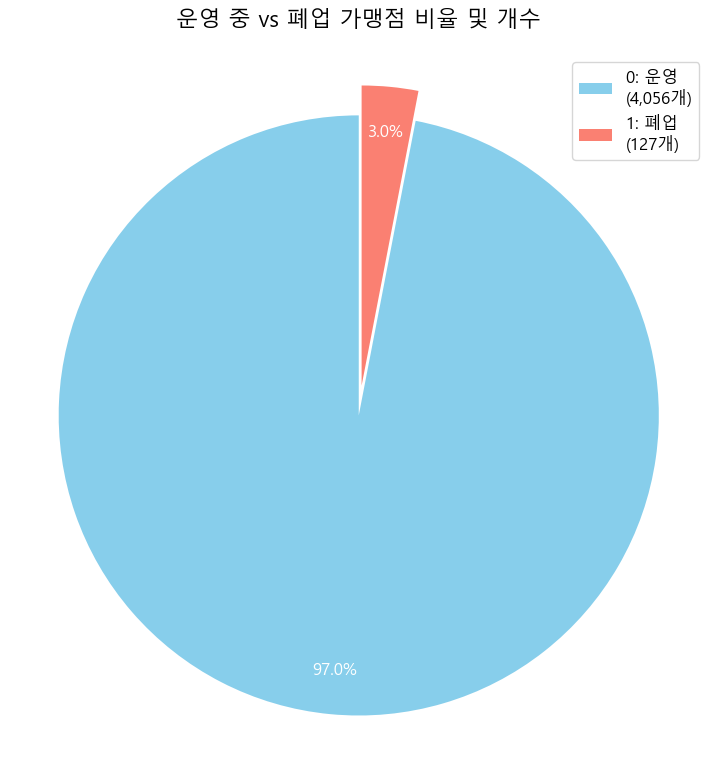

In [30]:
# 운영, 폐업한 가맹점 수, 비율


# 'TARGET' 컬럼의 값별 개수 계산
status_counts = df1_unique['TARGET'].value_counts()

# 만약 0 또는 1 값이 없다면 0으로 추가 (오류 방지)
if 0 not in status_counts.index:
    status_counts[0] = 0
if 1 not in status_counts.index:
    status_counts[1] = 0

# 인덱스 정렬 (0 다음에 1이 오도록)
status_counts = status_counts.sort_index()

# ----------------------------------------------------
# 2. 파이 차트 생성 (*** 라벨에 개수 추가 ***)
# ----------------------------------------------------

plt.figure(figsize=(9, 9)) # (사이즈 약간 조정)

# *** 라벨에 실제 개수 추가 ***
count_0 = status_counts[0]
count_1 = status_counts[1]
labels_with_counts = [
    f'0: 운영\n({count_0:,}개)', # 천 단위 콤마 추가
    f'1: 폐업\n({count_1:,}개)'
]

colors = ['skyblue', 'salmon'] # 운영=파랑, 폐업=빨강 계열
explode = (0, 0.1) # '폐업' 조각을 약간 강조

# 파이 차트 그리기 (수정된 라벨 사용)
patches, texts, autotexts = plt.pie(
    status_counts.values,
    # labels=labels_with_counts, # 라벨 대신 범례 사용 (텍스트 겹침 방지)
    colors=colors,
    explode=explode,
    autopct='%1.1f%%', # 소수점 첫째 자리까지 비율 표시
    startangle=90,     # 12시 방향에서 시작
    pctdistance=0.85,  # 비율 텍스트 위치
    textprops={'fontsize': 12} # 비율 텍스트 크기 조절
)

# 비율 텍스트 꾸미기
for autotext in autotexts:
    autotext.set_fontsize(12)
    autotext.set_color('white') # 비율 텍스트는 흰색으로

plt.title('운영 중 vs 폐업 가맹점 비율 및 개수', fontsize=16, pad=20)
plt.axis('equal') # 원형으로 보이도록 함

# *** 범례(Legend)에 라벨과 개수 표시 ***
plt.legend(
    patches, # (pie chart 객체)
    labels_with_counts, # (개수가 포함된 라벨)
    loc="best", # (가장 적절한 위치에 자동 배치)
    fontsize=12 # 범례 글자 크기 조절
)

In [9]:
cols = df.columns.tolist()

def find_cols(patterns):
    pats = patterns if isinstance(patterns, (list, tuple)) else [patterns]
    return [c for c in cols if any(p in c for p in pats)]

date_candidates = find_cols(["기준년월", "년월", "월", "date", "날짜"])
industry_candidates = find_cols(["업종", "업태", "category", "industry", "브랜드", "상권"])
sales_candidates = find_cols(["매출", "금액", "sales", "거래액", "판매액"])
macro_emp_cols = find_cols(["고용률"])
macro_unemp_cols = find_cols(["실업률"])
macro_activity_cols = find_cols(["경제활동"])

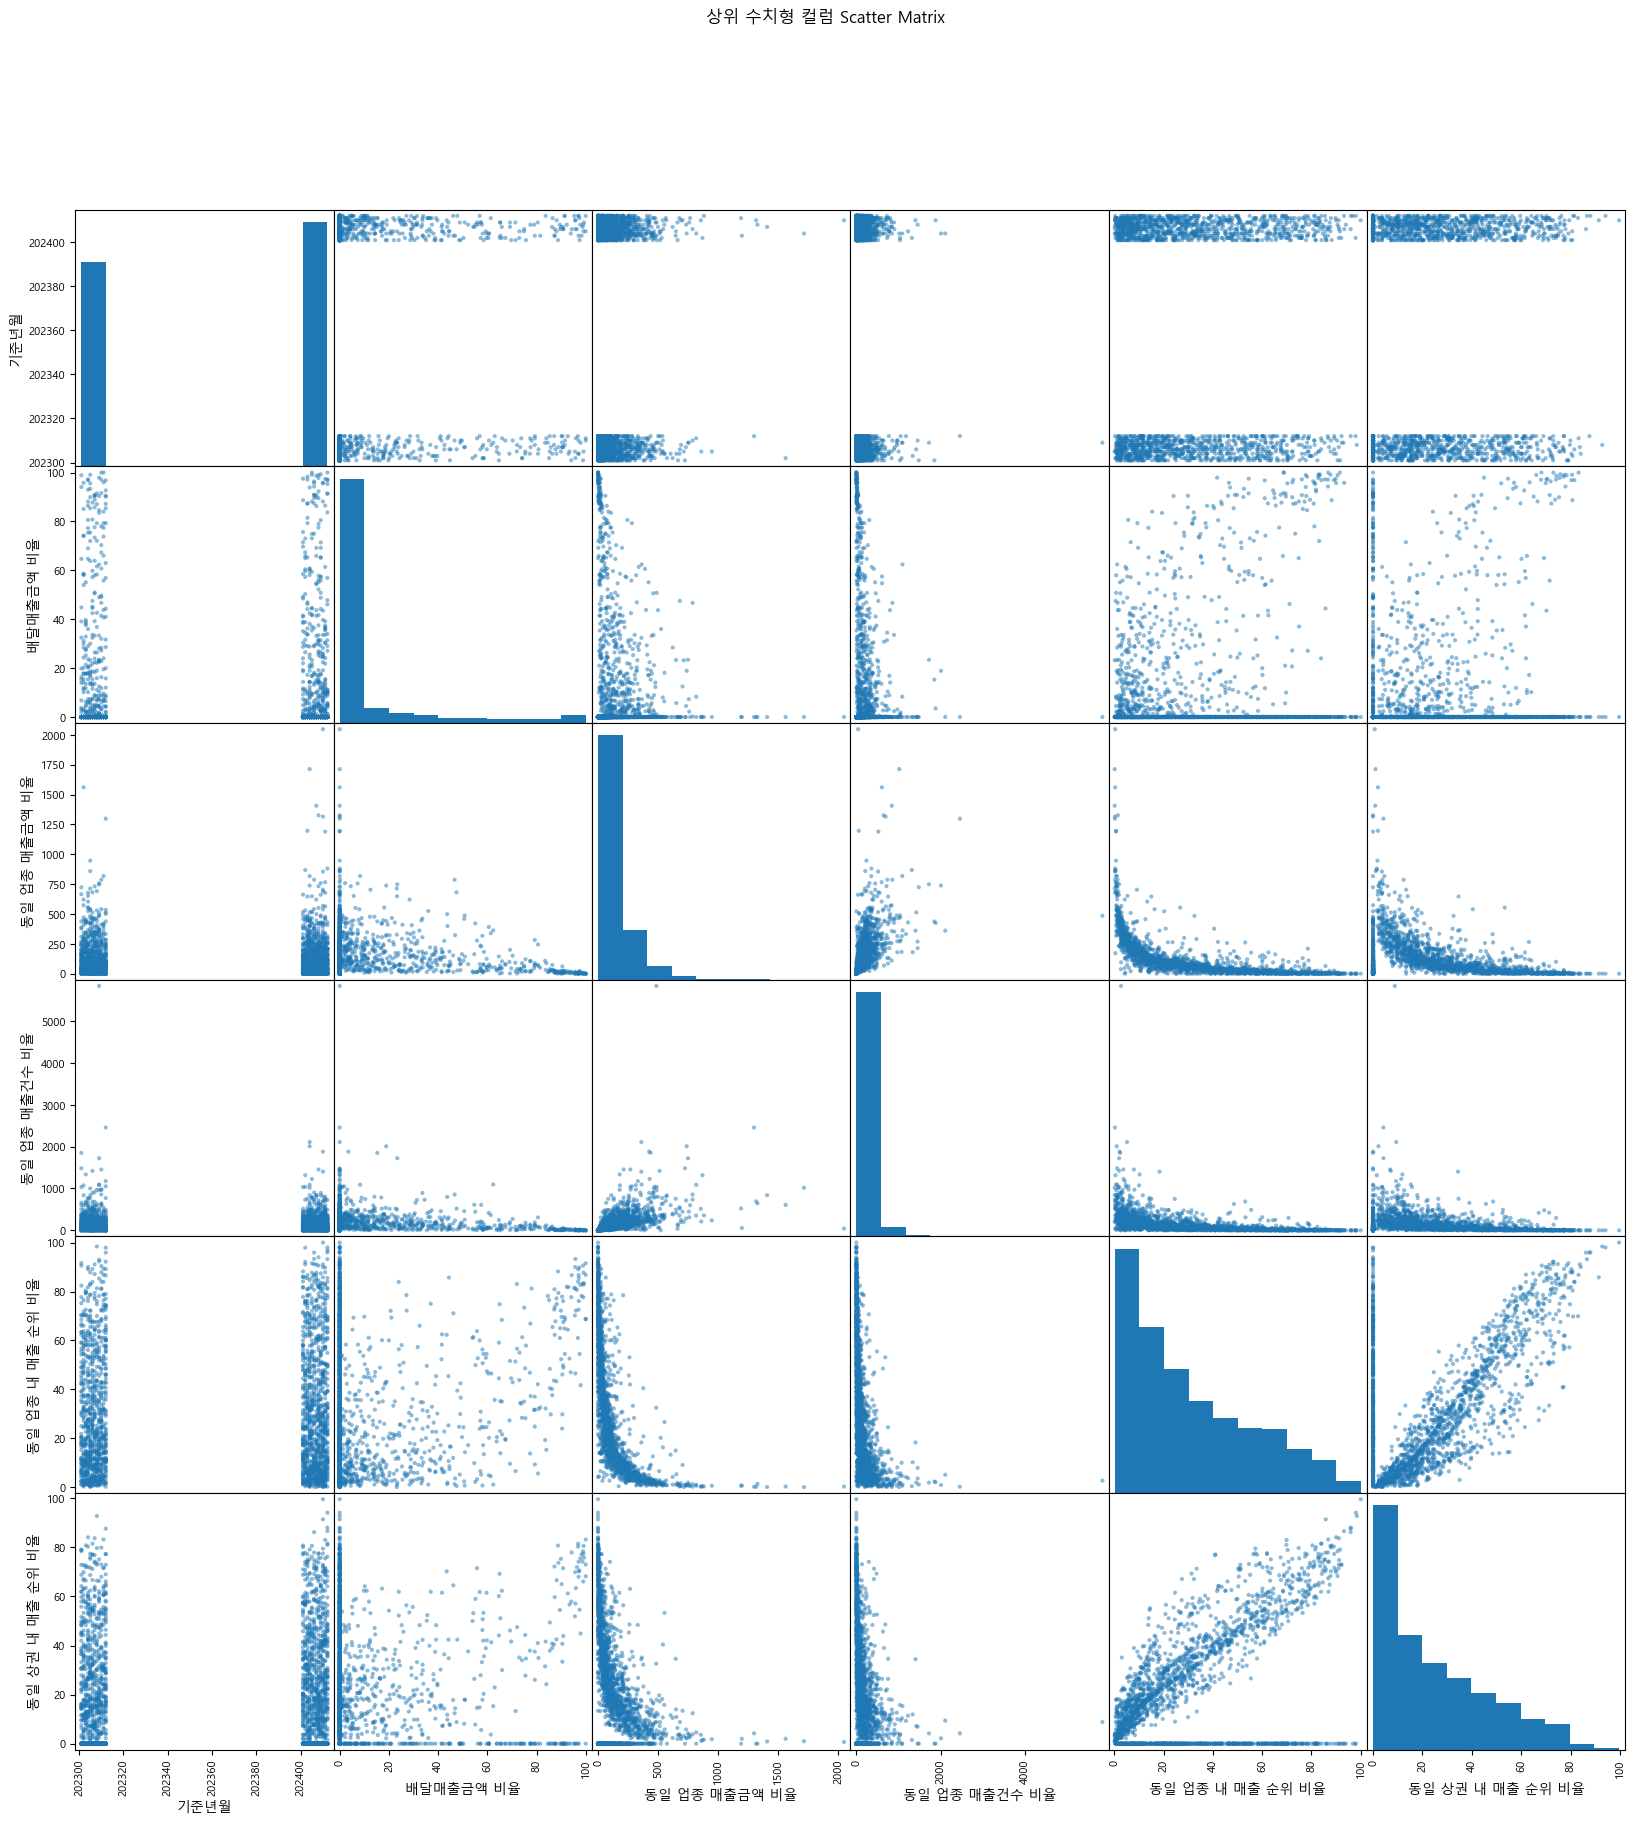

In [10]:
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix

# df가 이미 존재해야 합니다 (예: joined_last.csv 불러온 상태)
num_cols = df.select_dtypes(include=["number"]).columns.tolist()

# 상위 수치형 컬럼 최대 6개만 표시
sm_cols = num_cols[:min(6, len(num_cols))]

# 샘플링 (행이 많을 경우 2000개로 제한)
if len(sm_cols) >= 2:
    scatter_matrix(
        df[sm_cols].sample(min(2000, len(df))),
        figsize=(20,20),
        diagonal="hist"
    )
    plt.suptitle("상위 수치형 컬럼 Scatter Matrix")
    plt.show()
else:
    print("수치형 컬럼이 2개 이상 있어야 산점도 행렬을 그릴 수 있습니다.")
